# Financial Tweet Sentiment Classification — Tested Techniques

**Task:** classify the market sentiment of finance tweets as **Bearish (0) / Bullish (1) / Neutral (2)**.

This notebook documents every technique we experimented with, mapped to the project rubric:

1. Data Exploration · 2. Corpus Split · 3. Preprocessing · 4. Feature Engineering (BoW / word2vec / Transformer) · 5. Classification (classical ML + Transformer encoders + decoder LLM) · 6. Evaluation & Analysis.

It is **self-contained**: all project code is inlined in the Setup section below, so the notebook needs no external modules.

## Table of Contents

- [Setup](#setup)
  - [Imports](#imports)
  - [Configs](#configs)
  - [Utils functions](#utils-functions)
  - [Evaluate functions](#evaluate-functions)
  - [Preprocessing functions](#preprocessing-functions)
  - [EDA functions](#eda-functions)
  - [Word embedding functions](#word-embedding-functions)
    - [Sentence embedding functions - Transformer & decoder](#sentence-embedding-functions---transformer-decoder)
    - [1. Transformer trainer functions](#1-transformer-trainer-functions)
    - [2. Decoder (Qwen) functions](#2-decoder-qwen-functions)
- [1. Data Exploration](#1-data-exploration)
  - [1.1 Visual analysis](#11-visual-analysis)
  - [1.2 Word clouds per sentiment class](#12-word-clouds-per-sentiment-class)
  - [1.3 Conclusions](#13-conclusions)
- [2. Corpus Split](#2-corpus-split)
- [3. Data Preprocessing](#3-data-preprocessing)
- [4. Feature Engineering](#4-feature-engineering)
  - [4.1 Bag-of-Words family (BoW + TF-IDF)](#41-bag-of-words-family-bow-tf-idf)
  - [4.2 word2vec family](#42-word2vec-family)
  - [4.3 Transformer Encoder features](#43-transformer-encoder-features)
- [5. Classification Models](#5-classification-models)
  - [5.1 Traditional ML (≥2 variations each, ≥2 algorithms)](#51-traditional-ml-2-variations-each-2-algorithms)
  - [5.1b Class-Imbalance Strategies](#51b-class-imbalance-strategies)
  - [5.2 Transformer Encoders — fine-tuning (≥2 variations)](#52-transformer-encoders-fine-tuning-2-variations)
  - [5.3 Extra Transformer Encoders (Extra Work)](#53-extra-transformer-encoders-extra-work)
  - [5.4 Decoder model for classification](#54-decoder-model-for-classification)
- [6. Evaluation and Analysis](#6-evaluation-and-analysis)


## Setup

In [1]:
# Install dependencies (the notebook is otherwise self-contained).
%pip install -q numpy pandas scipy scikit-learn xgboost imbalanced-learn \
    nltk wordcloud matplotlib seaborn gensim \
    transformers datasets accelerate sentencepiece tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\MartaFeria\Documents\NovaIms\TextMining\Project\repo


### Imports

In [3]:
import os, sys, warnings, re, csv, json, argparse
from datetime import datetime
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import Image, display

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
from scipy.stats import chi2
from imblearn.over_sampling import RandomOverSampler, SMOTE

from gensim.models import Word2Vec
import gensim.downloader as api

# Transformer / decoder stack (used in Sections 4.3 and 5.2-5.4)
import torch
from tqdm import tqdm
from datasets import Dataset
from transformers import (
    AutoModel,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Quieter outputs (no progress-bar spam in the saved notebook).
os.environ["TQDM_DISABLE"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"


### Configs

In [4]:
# Reproducibility
SEED = 42

# Dataset splits
VAL_SIZE = 0.20
K_FOLD_N_SPLITS = 5

# Paths
TRAIN_CSV_PATH = "data/train.csv"
TEST_CSV_PATH = "data/test.csv"
RESULTS_CSV_PATH = "outputs/results.csv"
OUTPUT_PRED_PATH = "outputs/pred_best.csv"

# Error analysis output paths
CONF_MATRIX_PLOT_PATH = "outputs/confusion_matrix.png"
MISCLASSIFIED_TXT_PATH = "outputs/misclassified_report.txt"
MISCLASSIFIED_JSON_PATH = "outputs/misclassified_analysis.json"

# Labels
NUM_LABELS = 3
LABEL_NAMES = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
LABEL2ID = {"Bearish": 0, "Bullish": 1, "Neutral": 2}
ID2LABEL = {0: "Bearish", 1: "Bullish", 2: "Neutral"}

# DistilBERT
DISTILBERT_MODEL_NAME = "distilbert-base-uncased"
DISTILBERT_N_SAMPLES_SPIKE = 200
DISTILBERT_CACHE_DIR = "outputs/distilbert_cache"
DISTILBERT_CHECKPOINT_DIR = "outputs/distilbert_checkpoints"

# Qwen decoder
QWEN_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

# Twitter-RoBERTa
ROBERTA_MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
ROBERTA_N_SAMPLES_SPIKE = 200
ROBERTA_CACHE_DIR = "outputs/roberta_cache"
ROBERTA_CHECKPOINT_DIR = "outputs/roberta_checkpoints"

# FinBERT
FINBERT_MODEL_NAME = "ProsusAI/finbert"
FINBERT_N_SAMPLES_SPIKE = 200
FINBERT_CACHE_DIR = "outputs/finbert_cache"
FINBERT_CHECKPOINT_DIR = "outputs/finbert_checkpoints"

# DeBERTa-v3
DEBERTA_MODEL_NAME = "microsoft/deberta-v3-base"
DEBERTA_N_SAMPLES_SPIKE = 200
DEBERTA_CACHE_DIR = "outputs/deberta_cache"
DEBERTA_CHECKPOINT_DIR = "outputs/deberta_checkpoints"

# Feature matrix cache paths
BOW_TRAIN_PATH       = "outputs/X_train_bow.npz"
BOW_VAL_PATH         = "outputs/X_val_bow.npz"
TFIDF_UNI_TRAIN_PATH = "outputs/X_train_tfidf_uni.npz"
TFIDF_UNI_VAL_PATH   = "outputs/X_val_tfidf_uni.npz"
TFIDF_OPT_TRAIN_PATH = "outputs/X_train_tfidf_opt.npz"
TFIDF_OPT_VAL_PATH   = "outputs/X_val_tfidf_opt.npz"

# Leaderboard CSV schema
RESULTS_HEADERS = [
    "timestamp", "owner", "model_name", "feature_description",
    "accuracy", "precision_macro", "recall_macro", "f1_macro",
    "parameters", "f1_per_class", "notes",
]

# Preprocessing — placeholders
URL_PLACEHOLDER = "URL_PLACEHOLDER"
MENTION_PLACEHOLDER = "MENTION_PLACEHOLDER"
CASHTAG_PLACEHOLDER = "CASHTAG_PLACEHOLDER"
PROTECTED_PLACEHOLDERS = {URL_PLACEHOLDER, MENTION_PLACEHOLDER, CASHTAG_PLACEHOLDER}

# Preprocessing — financial noise tokens (used on top of NLTK stopwords)
FINANCIAL_STOPWORDS = {
    "rt", "amp", "co", "qt", "http", "https", "via",
    "stock", "stocks", "ticker", "tickers", "share", "shares",
}

# EDA — display
LABEL_PALETTE = {
    "Bearish": "#E06666",
    "Bullish": "#6AA84F",
    "Neutral": "#4A90E2",
}

# EDA — artifact detection patterns
URL_PATTERN     = re.compile(r'https?://\S+|www\.\S+')
MENTION_PATTERN = re.compile(r'@\w+')
CASHTAG_PATTERN = re.compile(r'\$\w+')
HASHTAG_PATTERN = re.compile(r'#\w+')

# EDA — fast stopword set (no NLTK dependency)
DEFAULT_STOPWORDS = {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours",
    "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself",
    "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which",
    "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be",
    "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an",
    "the", "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", "by",
    "for", "with", "about", "against", "between", "into", "through", "during", "before",
    "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over",
    "under", "again", "further", "then", "once", "here", "there", "when", "where", "why",
    "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such",
    "no", "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can",
    "will", "just", "don", "should", "now", "d", "ll", "m", "o", "re", "ve", "y",
    *FINANCIAL_STOPWORDS,
}

### Utils functions

In [5]:

def log_info(msg: str) -> None:
    print(f"[INFO] {msg}")

def log_success(msg: str) -> None:
    print(f"[SUCCESS] {msg}")

def log_error(msg: str) -> None:
    print(f"[ERROR] {msg}")

def log_warning(msg: str) -> None:
    print(f"[WARNING] {msg}")

def print_header(title: str, width: int = 60) -> None:
    print("=" * width)
    print(title)
    print("=" * width)

def print_separator(width: int = 60) -> None:
    print("-" * width)

### Evaluate functions

In [6]:
def compute_metrics(y_true, y_pred) -> dict:
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class = {
        name: float(per_class[i]) if i < len(per_class) else 0.0
        for i, name in LABEL_NAMES.items()
    }
    return {
        "accuracy": float(accuracy),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1),
        "f1_per_class": f1_per_class,
    }


def log_model_run(
    model_name: str,
    feature_desc: str,
    metrics: dict,
    params: str = "",
    owner: str = "",
    notes: str = "",
) -> None:
    """Logs a model run to results.csv idempotently — updates if the same key exists."""
    os.makedirs(os.path.dirname(RESULTS_CSV_PATH), exist_ok=True)

    new_row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "owner": owner,
        "model_name": model_name,
        "feature_description": feature_desc,
        "accuracy": f"{metrics['accuracy']:.4f}",
        "precision_macro": f"{metrics['precision_macro']:.4f}",
        "recall_macro": f"{metrics['recall_macro']:.4f}",
        "f1_macro": f"{metrics['f1_macro']:.4f}",
        "parameters": params,
        "f1_per_class": str(metrics.get("f1_per_class", "")),
        "notes": notes,
    }

    def _is_match(row: dict) -> bool:
        return (
            row["model_name"] == model_name
            and row["feature_description"] == feature_desc
            and row["parameters"] == params
            and row["owner"] == owner
        )

    existing_rows = []
    updated = False

    if os.path.exists(RESULTS_CSV_PATH) and os.path.getsize(RESULTS_CSV_PATH) > 0:
        try:
            with open(RESULTS_CSV_PATH, mode="r", newline="", encoding="utf-8") as f:
                reader = csv.reader(f)
                next(reader, None)
                for r in reader:
                    if len(r) != len(RESULTS_HEADERS):
                        continue
                    row = dict(zip(RESULTS_HEADERS, r))
                    if _is_match(row):
                        existing_rows.append(new_row)
                        updated = True
                    else:
                        existing_rows.append(row)
        except Exception as e:
            log_warning(f"Error reading leaderboard CSV: {e}. Resetting.")
            existing_rows = []

    if not updated:
        existing_rows.append(new_row)

    with open(RESULTS_CSV_PATH, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=RESULTS_HEADERS)
        writer.writeheader()
        writer.writerows(existing_rows)

    log_info(f"{'Updated' if updated else 'Added'} run in {RESULTS_CSV_PATH}")


def evaluate_and_log(
    y_true, y_pred,
    model_name: str,
    feature_desc: str,
    params: str = "",
    owner: str = "",
) -> dict:
    """Evaluates predictions, prints report, and logs to results.csv."""
    metrics = compute_metrics(y_true, y_pred)

    print_header(f"MODEL EVALUATION: {model_name} ({feature_desc})")
    log_info(f"Accuracy          : {metrics['accuracy']:.4f}")
    log_info(f"Precision (Macro) : {metrics['precision_macro']:.4f}")
    log_info(f"Recall (Macro)    : {metrics['recall_macro']:.4f}")
    log_info(f"F1 (Macro)        : {metrics['f1_macro']:.4f}")
    print_separator()
    print(classification_report(y_true, y_pred, target_names=list(LABEL_NAMES.values()), zero_division=0))
    print_separator()
    print(confusion_matrix(y_true, y_pred))

    log_model_run(model_name, feature_desc, metrics, params, owner=owner)
    return metrics


### Preprocessing functions

In [7]:
def _download_nltk_resources() -> None:
    resources = {
        'stopwords': 'corpora/stopwords',
        'punkt': 'tokenizers/punkt',
        'wordnet': 'corpora/wordnet',
        'omw-1.4': 'corpora/omw-1.4',
    }
    for name, path in resources.items():
        try:
            nltk.data.find(path)
        except LookupError:
            nltk.download(name, quiet=True)


_download_nltk_resources()

_SPACE_RE = re.compile(r'\s+')
_UNICODE_MAP = [
    (re.compile(r'[\u201c\u201d\u201e\u201f]'), '"'),
    (re.compile(r'[\u2018\u2019\u201a\u201b]'), "'"),
    (re.compile(r'[\u2012\u2013\u2014\u2015\u2212]'), '-'),
    (re.compile(r'\u2026'), '...'),
    (re.compile(r'\uFFFD'), ' '),
]
_TOKENIZER = TweetTokenizer(preserve_case=True, reduce_len=True, strip_handles=False)

# ── Text preprocessing ────────────────────────────────────────────────────────

def normalize_unicode_punctuation(text: str) -> str:
    if not isinstance(text, str):
        return ""
    for pattern, replacement in _UNICODE_MAP:
        text = pattern.sub(replacement, text)
    return text


def clean_regex(
    text: str,
    url_mode: str = 'replace',
    mention_mode: str = 'replace',
    cashtag_mode: str = 'keep',
) -> str:
    if url_mode == 'remove':
        text = URL_PATTERN.sub('', text)
    elif url_mode == 'replace':
        text = URL_PATTERN.sub(URL_PLACEHOLDER, text)

    if mention_mode == 'remove':
        text = MENTION_PATTERN.sub('', text)
    elif mention_mode == 'replace':
        text = MENTION_PATTERN.sub(MENTION_PLACEHOLDER, text)

    if cashtag_mode == 'remove':
        text = CASHTAG_PATTERN.sub('', text)
    elif cashtag_mode == 'replace':
        text = CASHTAG_PATTERN.sub(CASHTAG_PLACEHOLDER, text)

    return _SPACE_RE.sub(' ', text).strip()


def tokenize_tweet(text: str) -> list:
    return _TOKENIZER.tokenize(text)


def remove_stopwords_from_tokens(tokens: list, extra_stopwords: list = None) -> list:
    all_stops = set(stopwords.words('english')) | FINANCIAL_STOPWORDS
    if extra_stopwords:
        all_stops.update(extra_stopwords)
    return [t for t in tokens if (t.lower() not in all_stops) or (t in PROTECTED_PLACEHOLDERS)]


def apply_stemming(tokens: list) -> list:
    stemmer = PorterStemmer()
    return [t if t in PROTECTED_PLACEHOLDERS else stemmer.stem(t) for t in tokens]


def apply_lemmatization(tokens: list) -> list:
    lemmatizer = WordNetLemmatizer()
    return [t if t in PROTECTED_PLACEHOLDERS else lemmatizer.lemmatize(t) for t in tokens]


def preprocess_tweet(
    text: str,
    lowercase: bool = True,
    url_mode: str = 'replace',
    mention_mode: str = 'replace',
    cashtag_mode: str = 'keep',
    remove_stopwords: bool = True,
    custom_stopwords: list = None,
    use_stemming: bool = False,
    use_lemmatization: bool = True,
    return_str: bool = False,
):
    """Full tweet preprocessing pipeline. Returns token list or joined string."""
    text = normalize_unicode_punctuation(text)
    if lowercase:
        text = text.lower()
    text = clean_regex(text, url_mode=url_mode, mention_mode=mention_mode, cashtag_mode=cashtag_mode)
    tokens = tokenize_tweet(text)
    if remove_stopwords:
        tokens = remove_stopwords_from_tokens(tokens, extra_stopwords=custom_stopwords)
    if use_stemming:
        tokens = apply_stemming(tokens)
    if use_lemmatization:
        tokens = apply_lemmatization(tokens)
    return " ".join(tokens) if return_str else tokens


# ── Train / val splitting (absorbed from train_val_split.py) ──────────────────

def stratified_split(
    dataset: pd.DataFrame,
    test_size: float = VAL_SIZE,
    seed: int = SEED,
) -> tuple[pd.Series, pd.Series, pd.Series, pd.Series]:
    X, y = dataset['text'], dataset['label']
    return train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)


def create_stratified_kfold(n_splits: int = K_FOLD_N_SPLITS, seed: int = SEED) -> StratifiedKFold:
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

### EDA functions

In [8]:
# --- Core Analyzer Class ---

class DatasetAnalyzer:
    def __init__(self, file_path: str, name: str = "Dataset"):
        self.file_path = file_path
        self.name = name
        self.df = None
        self.has_label = False
        self.load_data()

    def load_data(self):
        """Loads dataset from CSV and determines if labels exist."""
        if not os.path.exists(self.file_path):
            raise FileNotFoundError(f"Dataset not found at: {self.file_path}")
        self.df = pd.read_csv(self.file_path)
        self.has_label = "label" in self.df.columns
        # Basic text cleaning to ensure str type
        self.df["text"] = self.df["text"].fillna("").astype(str)

    def analyze_basic_stats(self) -> dict:
        """Returns standard metrics on size, duplicates, and missing rows."""
        total_rows = len(self.df)
        exact_dups = self.df["text"].duplicated().sum()
        ci_dups = self.df["text"].str.lower().str.strip().duplicated().sum()
        empty_rows = (self.df["text"].str.strip() == "").sum()
        
        return {
            "total_rows": total_rows,
            "exact_duplicates": int(exact_dups),
            "trimmed_case_insensitive_duplicates": int(ci_dups),
            "empty_rows": int(empty_rows)
        }

    def analyze_class_distribution(self) -> list:
        """Returns class distribution metrics (counts, percentages) if labels are present."""
        if not self.has_label:
            return []
        
        counts = self.df["label"].value_counts().sort_index()
        total = counts.sum()
        dist = []
        for val, cnt in counts.items():
            dist.append({
                "label_id": int(val),
                "label_name": LABEL_NAMES.get(val, f"Unknown ({val})"),
                "count": int(cnt),
                "percentage": float((cnt / total * 100))
            })
        return dist

    def analyze_text_lengths(self) -> dict:
        """Computes text character length and token count statistics."""
        char_lens = self.df["text"].str.len()
        token_lens = self.df["text"].str.split().str.len()
        
        stats = {
            "char_len": {
                "mean": float(char_lens.mean()),
                "median": float(char_lens.median()),
                "std": float(char_lens.std()),
                "min": int(char_lens.min()),
                "max": int(char_lens.max())
            },
            "token_len": {
                "mean": float(token_lens.mean()),
                "median": float(token_lens.median()),
                "std": float(token_lens.std()),
                "min": int(token_lens.min()),
                "max": int(token_lens.max())
            }
        }
        
        # Breakdown by class if available
        if self.has_label:
            stats["by_class"] = {}
            for val, name in LABEL_NAMES.items():
                class_df = self.df[self.df["label"] == val]
                if not class_df.empty:
                    c_chars = class_df["text"].str.len()
                    c_tokens = class_df["text"].str.split().str.len()
                    stats["by_class"][name] = {
                        "char_mean": float(c_chars.mean()),
                        "char_median": float(c_chars.median()),
                        "token_mean": float(c_tokens.mean()),
                        "token_median": float(c_tokens.median())
                    }
        return stats

    def analyze_artifacts(self) -> dict:
        """Counts URLs, mentions, cashtags, and hashtags in the corpus."""
        def count_pat(text, pattern):
            return len(pattern.findall(text))
            
        n_urls = self.df["text"].apply(lambda t: count_pat(t, URL_PATTERN))
        n_mentions = self.df["text"].apply(lambda t: count_pat(t, MENTION_PATTERN))
        n_cashtags = self.df["text"].apply(lambda t: count_pat(t, CASHTAG_PATTERN))
        n_hashtags = self.df["text"].apply(lambda t: count_pat(t, HASHTAG_PATTERN))
        
        total = len(self.df)
        rates = {
            "average_per_tweet": {
                "urls": float(n_urls.mean()),
                "mentions": float(n_mentions.mean()),
                "cashtags": float(n_cashtags.mean()),
                "hashtags": float(n_hashtags.mean())
            },
            "presence_percentage": {
                "urls": float((n_urls > 0).sum() / total * 100),
                "mentions": float((n_mentions > 0).sum() / total * 100),
                "cashtags": float((n_cashtags > 0).sum() / total * 100),
                "hashtags": float((n_hashtags > 0).sum() / total * 100)
            }
        }

        # Breakdown by class if available
        if self.has_label:
            rates["by_class"] = {}
            for val, name in LABEL_NAMES.items():
                class_df = self.df[self.df["label"] == val]
                if not class_df.empty:
                    c_total = len(class_df)
                    rates["by_class"][name] = {
                        "urls_mean": float(class_df["text"].apply(lambda t: count_pat(t, URL_PATTERN)).mean()),
                        "mentions_mean": float(class_df["text"].apply(lambda t: count_pat(t, MENTION_PATTERN)).mean()),
                        "cashtags_mean": float(class_df["text"].apply(lambda t: count_pat(t, CASHTAG_PATTERN)).mean()),
                        "hashtags_mean": float(class_df["text"].apply(lambda t: count_pat(t, HASHTAG_PATTERN)).mean())
                    }
        return rates

    def analyze_non_ascii(self) -> dict:
        """Finds non-ASCII character rates and compiles some raw examples."""
        def has_non_ascii(text):
            return any(ord(c) > 127 for c in text)
            
        non_ascii_mask = self.df["text"].apply(has_non_ascii)
        n_non_ascii = non_ascii_mask.sum()
        total = len(self.df)
        
        # Get up to 5 examples
        examples = self.df[non_ascii_mask]["text"].head(5).tolist()
        
        return {
            "non_ascii_count": int(n_non_ascii),
            "non_ascii_percentage": float(n_non_ascii / total * 100),
            "examples": examples
        }

    def get_top_tokens(self, top_n: int = 15) -> dict:
        """Computes top N words across the dataset, excluding standard and financial stopwords."""
        # Simple token clean function
        def clean_split(text):
            # Strip URLs, mentions, cashtags first to get real words
            t = URL_PATTERN.sub('', text)
            t = MENTION_PATTERN.sub('', t)
            t = CASHTAG_PATTERN.sub('', t)
            t = HASHTAG_PATTERN.sub('', t)
            # Remove punctuation
            t = re.sub(r'[^a-zA-Z\s]', '', t)
            words = t.lower().split()
            return [w for w in words if w not in DEFAULT_STOPWORDS and len(w) > 2]

        top_tokens = {}
        
        # Global top words
        all_words = []
        for text in self.df["text"]:
            all_words.extend(clean_split(text))
        
        top_tokens["global"] = [{"word": w, "count": c} for w, c in Counter(all_words).most_common(top_n)]
        
        # Class specific top words
        if self.has_label:
            top_tokens["by_class"] = {}
            for val, name in LABEL_NAMES.items():
                class_df = self.df[self.df["label"] == val]
                c_words = []
                for text in class_df["text"]:
                    c_words.extend(clean_split(text))
                top_tokens["by_class"][name] = [{"word": w, "count": c} for w, c in Counter(c_words).most_common(top_n)]
                
        return top_tokens

    def generate_full_report(self, top_n_words: int = 15) -> dict:
        """Compiles all individual analytical components into a unified structured report."""
        return {
            "dataset_name": self.name,
            "file_path": self.file_path,
            "basic_stats": self.analyze_basic_stats(),
            "class_distribution": self.analyze_class_distribution(),
            "text_lengths": self.analyze_text_lengths(),
            "artifacts": self.analyze_artifacts(),
            "non_ascii": self.analyze_non_ascii(),
            "top_words": self.get_top_tokens(top_n=top_n_words)
        }

# --- Plot Generation Utility ---

def save_eda_plots(train_analyzer: DatasetAnalyzer, output_dir: str = "outputs/eda/"):
    """
    Generates and saves professional analytical figures under outputs/eda/.
    Requires matplotlib and seaborn. Skips gracefully if unavailable.
    """
    os.makedirs(output_dir, exist_ok=True)
    df = train_analyzer.df
    
    # Set tailored aesthetic style
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 10, 'figure.titlesize': 13})

    # Plot 1: Class Distribution
    if train_analyzer.has_label:
        dist = train_analyzer.analyze_class_distribution()
        dist_df = pd.DataFrame(dist)
        
        plt.figure(figsize=(6, 4))
        ax = sns.barplot(
            data=dist_df, x="label_name", y="count",
            palette=[LABEL_PALETTE[name] for name in dist_df["label_name"]],
            hue="label_name", legend=False
        )
        # Add labels
        for idx, row in dist_df.iterrows():
            ax.text(idx, row["count"] + 50, f"{row['count']}\n({row['percentage']:.2f}%)", ha="center")
            
        plt.title("Class Label Distribution (Training Set)", pad=15)
        plt.xlabel("Sentiment Class")
        plt.ylabel("Number of Tweets")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "class_distribution.png"), dpi=150)
        plt.close()

    # Plot 2: Length Distributions
    df["char_len"] = df["text"].str.len()
    df["token_len"] = df["text"].str.split().str.len()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    if train_analyzer.has_label:
        plot_df = df.assign(class_name=df["label"].map(LABEL_NAMES))
        sns.histplot(data=plot_df, x="char_len", hue="class_name", multiple="layer", bins=30, palette=LABEL_PALETTE, ax=axes[0])
        sns.histplot(data=plot_df, x="token_len", hue="class_name", multiple="layer", bins=20, palette=LABEL_PALETTE, ax=axes[1])
    else:
        sns.histplot(data=df, x="char_len", bins=30, color="#4A90E2", ax=axes[0])
        sns.histplot(data=df, x="token_len", bins=20, color="#4A90E2", ax=axes[1])
        
    axes[0].set_title("Character Length Distribution")
    axes[0].set_xlabel("Number of Characters")
    axes[1].set_title("Word (Token) Length Distribution")
    axes[1].set_xlabel("Number of Words")
    
    plt.suptitle("Tweet Length Distributions", y=0.98)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "length_distributions.png"), dpi=150)
    plt.close()

    # Plot 3: Artifact Rates by Class
    if train_analyzer.has_label:
        rates = train_analyzer.analyze_artifacts()
        by_class = rates.get("by_class", {})
        
        classes = list(by_class.keys())
        features = ["URLs", "Cashtags", "Hashtags", "Mentions"]
        
        plot_data = []
        for cls in classes:
            plot_data.append({
                "Class": cls,
                "URLs": by_class[cls]["urls_mean"],
                "Cashtags": by_class[cls]["cashtags_mean"],
                "Hashtags": by_class[cls]["hashtags_mean"],
                "Mentions": by_class[cls]["mentions_mean"]
            })
        
        rates_df = pd.DataFrame(plot_data).melt(id_vars="Class", var_name="Artifact", value_name="Average Count")
        
        plt.figure(figsize=(9, 4.5))
        sns.barplot(data=rates_df, x="Artifact", y="Average Count", hue="Class", palette=LABEL_PALETTE)
        plt.title("Average Metadata Artifact Rates Grouped by Sentiment Class", pad=15)
        plt.xlabel("Tweet Metadata Type")
        plt.ylabel("Average Count per Tweet")
        plt.legend(title="Sentiment Class")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "artefact_rates_by_class.png"), dpi=150)
        plt.close()

    # Plot 4: Top Words by Class
    if train_analyzer.has_label:
        top_words = train_analyzer.get_top_tokens(top_n=10)
        by_class = top_words.get("by_class", {})
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        for ax, (cls_name, words) in zip(axes, by_class.items()):
            words_df = pd.DataFrame(words)
            if not words_df.empty:
                sns.barplot(data=words_df, x="count", y="word", color=LABEL_PALETTE[cls_name], ax=ax)
            ax.set_title(f"Top Words in {cls_name} Tweets")
            ax.set_xlabel("Occurrence Frequency")
            ax.set_ylabel("")
            
        plt.suptitle("Top Highly Informative Sentiment Vocabularies", y=0.98)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "top_words_by_class.png"), dpi=150)
        plt.close()
        
    log_success(f"EDA plots saved to {output_dir}")

# --- Output Formatters ---

def print_markdown_report(train_rpt: dict, test_rpt: dict = None):
    """Prints a beautiful, comprehensive Markdown formatted report to stdout."""
    print(f"# Exploratory Data Analysis (EDA) Report")
    print(f"**Generative Analysis for Corpus Pipelines**\n")
    
    # 1. Dataset Overview
    print("## [1] Dataset Size & Integrity Overview")
    print("| Dataset | Total Rows | Exact Duplicates | Trimmed Insensitive Dups | Empty Rows |")
    print("| :--- | :---: | :---: | :---: | :---: |")
    tr = train_rpt["basic_stats"]
    print(f"| **Train** | {tr['total_rows']:,} | {tr['exact_duplicates']} | {tr['trimmed_case_insensitive_duplicates']} | {tr['empty_rows']} |")
    if test_rpt:
        te = test_rpt["basic_stats"]
        print(f"| **Test** | {te['total_rows']:,} | {te['exact_duplicates']} | {te['trimmed_case_insensitive_duplicates']} | {te['empty_rows']} |")
    print()

    # 2. Class Distribution
    if train_rpt["class_distribution"]:
        print("## [2] Sentiment Class Distributions (Train Set)")
        print("| Label ID | Sentiment Class | Count | Percentage | Chart representation |")
        print("| :---: | :--- | :---: | :---: | :--- |")
        for row in train_rpt["class_distribution"]:
            bar = "=" * int(row["percentage"] / 5)
            print(f"| `{row['label_id']}` | **{row['label_name']}** | {row['count']:,} | {row['percentage']:.2f}% | `{bar}` |")
        print("\n> **Strategic Note**: Standard ML algorithms will show bias to the majority Neutral class. Set class weight parameters to 'balanced' or implement cross-validation splitting accordingly.\n")

    # 3. Tweet Length Statistics
    print("## [3] Sequence Length Analyses")
    l_tr = train_rpt["text_lengths"]
    print("### Character Lengths:")
    print(f"* **Train**: Mean = {l_tr['char_len']['mean']:.1f} chars, Std = {l_tr['char_len']['std']:.1f}, Min/Max = {l_tr['char_len']['min']}/{l_tr['char_len']['max']}")
    if test_rpt:
        l_te = test_rpt["text_lengths"]
        print(f"* **Test**: Mean = {l_te['char_len']['mean']:.1f} chars, Std = {l_te['char_len']['std']:.1f}, Min/Max = {l_te['char_len']['min']}/{l_te['char_len']['max']}")
    
    print("\n### Word (Token) Counts:")
    print(f"* **Train**: Mean = {l_tr['token_len']['mean']:.1f} words, Std = {l_tr['token_len']['std']:.1f}, Min/Max = {l_tr['token_len']['min']}/{l_tr['token_len']['max']}")
    if test_rpt:
        print(f"* **Test**: Mean = {l_te['token_len']['mean']:.1f} words, Std = {l_te['token_len']['std']:.1f}, Min/Max = {l_te['token_len']['min']}/{l_te['token_len']['max']}")
    
    if "by_class" in l_tr:
        print("\n### Sequence Characteristics Grouped by Class (Train):")
        print("| Sentiment Class | Avg Character Length | Avg Word (Token) Count |")
        print("| :--- | :---: | :---: |")
        for cls_name, vals in l_tr["by_class"].items():
            print(f"| **{cls_name}** | {vals['char_mean']:.1f} characters | {vals['token_mean']:.1f} tokens |")
    print()

    # 4. Artifact Analysis
    print("## [4] Twitter Metadata Artifact Rates")
    art = train_rpt["artifacts"]
    print("| Metadata Type | Average Occurrences / Tweet | Percentage of Tweets Containing Feature |")
    print("| :--- | :---: | :---: |")
    for feat in ["urls", "cashtags", "hashtags", "mentions"]:
        print(f"| **{feat.upper()}** | {art['average_per_tweet'][feat]:.3f} | {art['presence_percentage'][feat]:.1f}% |")
    
    if "by_class" in art:
        print("\n### Average Metadata Artifact Occurrences Grouped by Class (Train):")
        print("| Sentiment Class | Avg URLs / Tweet | Avg Cashtags / Tweet | Avg Hashtags / Tweet | Avg Mentions / Tweet |")
        print("| :--- | :---: | :---: | :---: | :---: |")
        for cls_name, vals in art["by_class"].items():
            print(f"| **{cls_name}** | {vals['urls_mean']:.3f} | {vals['cashtags_mean']:.3f} | {vals['hashtags_mean']:.3f} | {vals['mentions_mean']:.3f} |")
    print("\n> **Strategic Note**: URLs are highly associated with Neutral (news) tweets. Removing URLs completely strips this structural feature; utilizing a unified placeholder `URL_PLACEHOLDER` is highly recommended.\n")

    # 5. Non-ASCII Analysis
    print("## [5] Non-ASCII & Unicode Anomalies")
    non_tr = train_rpt["non_ascii"]
    print(f"* **Train**: {non_tr['non_ascii_count']:,} tweets ({non_tr['non_ascii_percentage']:.2f}%) contain smart quotes, long dashes, smart apostrophes, or replacement symbols.")
    if test_rpt:
        non_te = test_rpt["non_ascii"]
        print(f"* **Test**: {non_te['non_ascii_count']:,} tweets ({non_te['non_ascii_percentage']:.2f}%) contain smart quotes, long dashes, smart apostrophes, or replacement symbols.")
    
    print("\n### Sample raw sentences showing Unicode irregularities:")
    for ex in non_tr["examples"]:
        # Clean sample sentences of emojis in case they cause issues when printed in samples
        clean_ex = re.sub(r'[^\x00-\x7F]+', ' ', ex)
        print(f"* `{clean_ex}`")
    print()

    # 6. Vocabularies
    print("## [6] Most Frequent Sentiment Vocabularies (Excluding Noise)")
    top_w = train_rpt["top_words"]
    print("### Top Overall Vocabularies:")
    print(", ".join([f"**{row['word']}** ({row['count']})" for row in top_w["global"]]))
    
    if "by_class" in top_w:
        print("\n### Top Vocabularies by Class (Train):")
        for cls_name, words in top_w["by_class"].items():
            word_list = ", ".join([f"**{row['word']}** ({row['count']})" for row in words[:8]])
            print(f"* **{cls_name}**: {word_list}")
    print()

### Word embedding functions


In [9]:
def _get_vocab_and_vectors(embedding_model):
    if hasattr(embedding_model, 'key_to_index'):
        return embedding_model.key_to_index, embedding_model
    if hasattr(embedding_model, 'wv') and hasattr(embedding_model.wv, 'key_to_index'):
        return embedding_model.wv.key_to_index, embedding_model.wv
    return embedding_model, embedding_model


def calculate_oov(tokenized_sentences: list, embedding_model) -> tuple[float, float, set]:
    """Returns (unique_oov_rate, token_oov_rate, oov_word_set) for the tokenized corpus."""
    vocab, _ = _get_vocab_and_vectors(embedding_model)
    all_tokens = [tok for sent in tokenized_sentences for tok in sent]
    unique_tokens = set(all_tokens)
    if not unique_tokens:
        return 0.0, 0.0, set()
    oov_unique = {tok for tok in unique_tokens if tok not in vocab}
    oov_tokens = [tok for tok in all_tokens if tok not in vocab]
    return len(oov_unique) / len(unique_tokens), len(oov_tokens) / len(all_tokens), oov_unique


def vectorize_corpus(tokenized_sentences: list, embedding_model, vector_size: int = 100) -> np.ndarray:
    """Mean-pools token embeddings for each sentence in the corpus."""
    vocab, vectors = _get_vocab_and_vectors(embedding_model)
    result = []
    for sent in tokenized_sentences:
        valid = [vectors[tok] for tok in sent if tok in vocab]
        result.append(np.mean(valid, axis=0) if valid else np.zeros(vector_size))
    return np.array(result)


def vectorize_document_tfidf(tokens, vocab, vectors, tfidf_row, tfidf_vocab, vector_size=100):
    """Vectorizes a single document using TF-IDF weighted mean pooling."""
    weighted_vectors = []
    weights = []
    for tok in tokens:
        if tok in vocab and tok in tfidf_vocab:
            weight = tfidf_row[0, tfidf_vocab[tok]]
            if weight > 0:
                weighted_vectors.append(vectors[tok] * weight)
                weights.append(weight)
    if not weighted_vectors:
        return np.zeros(vector_size)
    return np.sum(weighted_vectors, axis=0) / np.sum(weights)


def vectorize_corpus_tfidf(tokenized_sentences, embedding_model, tfidf_matrix, tfidf_vectorizer, vector_size=100):
    """Vectorizes a full corpus using TF-IDF weighted mean pooling."""
    vocab, vectors = _get_vocab_and_vectors(embedding_model)
    tfidf_vocab = tfidf_vectorizer.vocabulary_
    return np.array([
        vectorize_document_tfidf(
            tokens=sent,
            vocab=vocab,
            vectors=vectors,
            tfidf_row=tfidf_matrix[i],
            tfidf_vocab=tfidf_vocab,
            vector_size=vector_size
        )
        for i, sent in enumerate(tokenized_sentences)
    ])


def train_word2vec(tokenized_sentences: list, vector_size: int = 100, window: int = 5, min_count: int = 2, sg: int = 0) -> Word2Vec:
    """Trains a Word2Vec model on the given tokenized corpus."""
    model = Word2Vec(
        sentences=tokenized_sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=sg,
        seed=SEED,
        workers=4,
    )
    log_success(f"Word2Vec trained — vocab size: {len(model.wv.key_to_index)}")
    return model


def load_glove_twitter(dim: int = 100):
    """Loads GloVe-Twitter embeddings via gensim downloader (downloads ~400 MB if not cached)."""
    log_info(f"Loading glove-twitter-{dim} (downloads if not cached) ...")
    try:
        model = api.load(f"glove-twitter-{dim}")
        log_success(f"GloVe-Twitter-{dim} loaded — vocab size: {len(model.key_to_index)}")
        return model
    except Exception as e:
        log_error(f"Failed to load GloVe-Twitter-{dim}: {e}")
        raise


In [10]:
# === Experiment functions ===

def run_model_pipeline(
    X_train_vec, X_val_vec, y_train, y_val,
    model, model_name: str, feature_desc: str, params_str: str,
) -> dict:
    """Fits a classifier on pre-vectorized features, evaluates on val, logs idempotently."""
    model.fit(X_train_vec, y_train)
    return evaluate_and_log(
        y_val, model.predict(X_val_vec),
        model_name=model_name,
        feature_desc=feature_desc,
        params=params_str,
    )


def run_classifier(model, X_train_vec, X_val_vec, y_train, y_val,
                   model_name: str, feature_desc: str, params_str: str) -> dict:
    return run_model_pipeline(X_train_vec, X_val_vec, y_train, y_val,
                              model, model_name, feature_desc, params_str)


#### Sentence embedding functions - Transformer & decoder

In [11]:
def extract_embeddings(texts, model_path, pooling="cls", batch_size=32):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    log_info(f"Loading {model_path} on {device}...")
    
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModel.from_pretrained(model_path)
    model.to(device)
    model.eval()

    all_embs = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=f"Extracting {pooling} from {model_path}"):
            batch = texts[i:i+batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
            encoded = {k: v.to(device) for k, v in encoded.items()}
            
            out = model(**encoded)
            hidden = out.last_hidden_state  # (B, L, H)
            
            if pooling == "cls":
                emb = hidden[:, 0, :]
            elif pooling == "mean":
                mask = encoded["attention_mask"].unsqueeze(-1).expand(hidden.size()).float()
                sum_emb = torch.sum(hidden * mask, 1)
                sum_mask = torch.clamp(mask.sum(1), min=1e-9)
                emb = sum_emb / sum_mask
            else:
                raise ValueError("Pooling must be cls or mean")
                
            all_embs.append(emb.cpu().numpy())
            
    return np.vstack(all_embs)

def encoder_features(texts, pooling="cls", batch_size=32, model_path=None):
    """Sentence embeddings from a frozen (not fine-tuned) encoder, as a feature matrix."""
    if model_path is None:
        model_path = DISTILBERT_MODEL_NAME
    return extract_embeddings(list(texts), model_path, pooling=pooling, batch_size=batch_size)


#### 1. Transformer trainer functions

In [12]:
MAX_LENGTH = 128


@dataclass(frozen=True)
class TrainerSpec:
    """Everything that distinguishes one encoder trainer from another."""

    display_name: str   # label used in the results leaderboard
    model_name: str     # HF hub id
    cache_dir: str      # tokenized-dataset cache root
    checkpoint_dir: str  # Trainer output root


# All four encoders differ only in config, so they live here as a registry.
# Add a new backbone by adding one entry.
SPECS: dict[str, TrainerSpec] = {
    "distilbert": TrainerSpec("DistilBERT", DISTILBERT_MODEL_NAME,
                              DISTILBERT_CACHE_DIR, DISTILBERT_CHECKPOINT_DIR),
    "finbert":    TrainerSpec("FinBERT", FINBERT_MODEL_NAME,
                              FINBERT_CACHE_DIR, FINBERT_CHECKPOINT_DIR),
    "roberta":    TrainerSpec("Twitter-RoBERTa", ROBERTA_MODEL_NAME,
                              ROBERTA_CACHE_DIR, ROBERTA_CHECKPOINT_DIR),
    "deberta":    TrainerSpec("deberta-v3-base", DEBERTA_MODEL_NAME,
                              DEBERTA_CACHE_DIR, DEBERTA_CHECKPOINT_DIR),
}


def load_tokenizer(spec: TrainerSpec) -> AutoTokenizer:
    log_info(f"Loading tokenizer: {spec.model_name}")
    tokenizer = AutoTokenizer.from_pretrained(spec.model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return tokenizer


def _tokenize_dataset(tokenizer, texts, labels=None, max_length: int = MAX_LENGTH) -> Dataset:
    """Build a tokenized HF Dataset from texts (and optional labels)."""
    data = {"text": list(texts)}
    if labels is not None:
        data["label"] = list(labels)
    return Dataset.from_dict(data).map(
        lambda batch: tokenizer(batch["text"], truncation=True, max_length=max_length),
        batched=True,
        remove_columns=["text"],
    )


def build_hf_datasets(tokenizer, X_train, X_val, y_train, y_val, cache_dir: Path,
                      max_length: int = MAX_LENGTH):
    cache_dir.mkdir(parents=True, exist_ok=True)

    def _build(texts, labels, cache_path):
        if cache_path.exists():
            log_info(f"Loading dataset from cache: {cache_path}")
            return Dataset.load_from_disk(str(cache_path))
        ds = _tokenize_dataset(tokenizer, texts, labels, max_length=max_length)
        ds.save_to_disk(str(cache_path))
        log_info(f"Dataset cached to: {cache_path}")
        return ds

    return (_build(X_train, y_train, cache_dir / "train"),
            _build(X_val,   y_val,   cache_dir / "val"))


def make_compute_metrics(spec: TrainerSpec, notes: str = "", params: str = ""):
    def _compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        metrics = compute_metrics(labels, preds)
        log_model_run(
            model_name=spec.display_name,
            feature_desc="HF fine-tune",
            metrics=metrics,
            params=params or f"model={spec.model_name}, max_length={MAX_LENGTH}",
            notes=notes,
        )
        return {"accuracy": metrics["accuracy"], "f1_macro": metrics["f1_macro"]}
    return _compute_metrics


def build_trainer(spec: TrainerSpec, model, tokenizer, train_ds, val_ds, notes: str = "",
                  learning_rate: float = 2e-5, batch_size: int = 16,
                  seed: int = SEED, params: str = "") -> Trainer:
    training_args = TrainingArguments(
        output_dir=str(Path(spec.checkpoint_dir) / spec.model_name.replace("/", "_")),
        num_train_epochs=3,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=seed,
        logging_steps=50,
        report_to="none",
    )
    return Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=make_compute_metrics(spec, notes=notes, params=params),
    )


def run_trainer(model: str, n_samples: int | None = 500, notes: str = "",
                learning_rate: float = 2e-5, max_length: int = MAX_LENGTH,
                seed: int = SEED, batch_size: int = 16) -> Trainer:
    """Fine-tune one of the registered encoders.

    `model` is a key of SPECS: "distilbert", "finbert", "roberta", "deberta".
    `learning_rate`, `max_length`, `seed` and `batch_size` allow controlled
    variations; each combination gets its own leaderboard row and dataset cache.
    """
    spec = SPECS[model]

    log_info(f"Loading {'all' if n_samples is None else n_samples} samples ...")
    df = pd.read_csv(TRAIN_CSV_PATH)
    if n_samples:
        df = df.sample(n=n_samples, random_state=SEED).reset_index(drop=True)
    X_train, X_val, y_train, y_val = stratified_split(df)
    log_info(f"Split — train={len(X_train)}, val={len(X_val)}")

    tokenizer = load_tokenizer(spec)

    # Sample-size-specific cache dir so a 500-sample spike isn't served when we
    # ask for the full dataset. max_length variants get their own cache too.
    suffix = "full" if n_samples is None else f"n{n_samples}"
    if max_length != MAX_LENGTH:
        suffix += f"_len{max_length}"
    cache_dir = Path(spec.cache_dir) / suffix
    train_ds, val_ds = build_hf_datasets(tokenizer, X_train, X_val, y_train, y_val, cache_dir,
                                         max_length=max_length)
    log_info(f"Datasets — train={len(train_ds)} rows, val={len(val_ds)} rows")

    log_info(f"Loading {spec.model_name} sequence classifier ...")
    # ignore_mismatched_sizes=True safely re-initializes the classification head
    # for our project's 3-label schema.
    hf_model = AutoModelForSequenceClassification.from_pretrained(
        spec.model_name,
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )

    params = (f"model={spec.model_name}, max_length={max_length}, lr={learning_rate}, "
              f"seed={seed}, n={'full' if n_samples is None else n_samples}")
    trainer = build_trainer(spec, hf_model, tokenizer, train_ds, val_ds, notes=notes,
                            learning_rate=learning_rate, batch_size=batch_size,
                            seed=seed, params=params)

    log_info("Starting training ...")
    trainer.train()
    log_info("Running final evaluation ...")
    trainer.evaluate()
    log_success("Training complete.")
    return trainer


#### 2. Decoder (Qwen) functions

In [13]:
LABEL_TO_ID = {v.lower(): k for k, v in LABEL_NAMES.items()}
MAJORITY_FALLBACK = 2  # Neutral — dominant class (~62 % of train set)

SYSTEM_PROMPT = (
    "You are a financial sentiment classifier for tweets about stocks. "
    "Each tweet is one of three classes: Bearish, Bullish, or Neutral. "
    "Reply with exactly ONE word — the class name — and nothing else."
)


# ── Model loading ────────────────────────────────────────────────────────────

def load_qwen(
    device: str | None = None,
    dtype: torch.dtype | None = None,
) -> tuple[AutoTokenizer, AutoModelForCausalLM]:
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    if dtype is None:
        dtype = torch.bfloat16 if device == "cuda" else torch.float32

    log_info(f"Loading tokenizer: {QWEN_MODEL_NAME}")
    tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL_NAME)
    # Decoder-only models need left padding so the last token == the prediction position.
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    log_info(f"Loading model on {device} with dtype={dtype} ...")
    model = AutoModelForCausalLM.from_pretrained(
        QWEN_MODEL_NAME,
        torch_dtype=dtype,
        device_map=device,
    )
    model.eval()
    log_success("Qwen ready.")
    return tokenizer, model


# ── Prompt construction ──────────────────────────────────────────────────────

def _sample_few_shot_examples(train_df: pd.DataFrame, n_per_class: int, seed: int) -> list[tuple[str, str]]:
    examples: list[tuple[str, str]] = []
    rng = np.random.RandomState(seed)
    for label_id, label_name in LABEL_NAMES.items():
        pool = train_df.loc[train_df["label"] == label_id, "text"].tolist()
        idxs = rng.choice(len(pool), size=min(n_per_class, len(pool)), replace=False)
        for i in idxs:
            examples.append((pool[i], label_name))
    rng.shuffle(examples)  # avoid grouping by class
    return examples


def build_few_shot_messages(
    train_df: pd.DataFrame,
    n_per_class: int = 2,
    seed: int = SEED,
) -> list[dict]:
    messages: list[dict] = [{"role": "system", "content": SYSTEM_PROMPT}]
    for text, label_name in _sample_few_shot_examples(train_df, n_per_class, seed):
        messages.append({"role": "user", "content": f"Tweet: {text}"})
        messages.append({"role": "assistant", "content": label_name})
    return messages


# ── Inference ────────────────────────────────────────────────────────────────

_LABEL_REGEX = re.compile(r"(bearish|bullish|neutral)", re.IGNORECASE)


def _parse_label(generated_text: str) -> int | None:
    m = _LABEL_REGEX.search(generated_text[:32])
    if m is None:
        return None
    return LABEL_TO_ID[m.group(1).lower()]


def _build_chat_string(tokenizer, few_shot_messages: list[dict], tweet: str) -> str:
    messages = list(few_shot_messages) + [{"role": "user", "content": f"Tweet: {tweet}"}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


@torch.no_grad()
def classify_batch(
    tokenizer,
    model,
    few_shot_messages: list[dict],
    tweets: list[str],
    batch_size: int = 8,
    max_new_tokens: int = 4,
) -> tuple[list[int], int]:
    preds: list[int] = []
    parse_fails = 0
    device = next(model.parameters()).device

    for start in range(0, len(tweets), batch_size):
        chunk = tweets[start:start + batch_size]
        prompts = [_build_chat_string(tokenizer, few_shot_messages, t) for t in chunk]
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=2048).to(device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
        new_tokens = outputs[:, inputs["input_ids"].shape[1]:]
        decoded = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)

        for text in decoded:
            pid = _parse_label(text)
            if pid is None:
                parse_fails += 1
                preds.append(MAJORITY_FALLBACK)
            else:
                preds.append(pid)

        if (start // batch_size) % 10 == 0:
            log_info(f"  classified {start + len(chunk)}/{len(tweets)} (fails so far: {parse_fails})")

    return preds, parse_fails


def run_qwen_eval(
    owner: str = "La Feria",
    notes: str = "TM-031 EXTRA WORK +1.0pt",
    n_per_class: int = 2,
    batch_size: int = 8,
    device: str | None = None,
    val_subset: int | None = None,
    tokenizer=None,
    model=None,
) -> dict:
    df = pd.read_csv(TRAIN_CSV_PATH)
    X_train, X_val, y_train, y_val = stratified_split(df)
    train_df = pd.DataFrame({"text": X_train.values, "label": y_train.values})

    if val_subset is not None:
        X_val = X_val.iloc[:val_subset]
        y_val = y_val.iloc[:val_subset]

    if tokenizer is None or model is None:
        tokenizer, model = load_qwen(device=device)
    few_shot_messages = build_few_shot_messages(train_df, n_per_class=n_per_class, seed=SEED)
    n_shots = n_per_class * NUM_LABELS

    log_info(f"Classifying {len(X_val)} val tweets with {n_shots}-shot Qwen ...")
    preds, parse_fails = classify_batch(
        tokenizer, model, few_shot_messages, X_val.tolist(), batch_size=batch_size,
    )
    parse_fail_rate = parse_fails / max(len(preds), 1)
    if parse_fail_rate > 0:
        log_warning(f"Parse-failure rate: {parse_fail_rate:.2%} ({parse_fails}/{len(preds)})")

    metrics = compute_metrics(y_val.values, np.array(preds))

    log_model_run(
        model_name="Qwen2.5-1.5B-Instruct",
        feature_desc=f"few-shot {n_shots}-shot ({n_per_class}/class) chat template",
        metrics=metrics,
        params=f"dtype=bf16, greedy, max_new_tokens=4, seed={SEED}, batch={batch_size}",
        owner=owner,
        notes=f"{notes}; parse_fail_rate={parse_fail_rate:.2%}",
    )
    log_success(f"Qwen run logged. f1_macro={metrics['f1_macro']:.4f}")
    return metrics


## 1. Data Exploration

We profile the corpora with the `DatasetAnalyzer`, which computes size/integrity,
class distribution, sequence-length statistics, Twitter-artifact rates (URLs, mentions, cashtags,
hashtags), non-ASCII anomalies, and the most frequent tokens per class.

In [14]:
train_analyzer = DatasetAnalyzer(TRAIN_CSV_PATH, name="Train")
test_analyzer  = DatasetAnalyzer(TEST_CSV_PATH,  name="Test")

train_report = train_analyzer.generate_full_report()
test_report  = test_analyzer.generate_full_report()

print(f"Train rows: {train_report['basic_stats']['total_rows']:,}  |  "
      f"Test rows: {test_report['basic_stats']['total_rows']:,}")
train_analyzer.df.head()

Train rows: 9,543  |  Test rows: 2,388


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


In [15]:
# Structured text report (size, class balance, lengths, artifacts, non-ASCII, top words)
print_markdown_report(train_report, test_report)

# Exploratory Data Analysis (EDA) Report
**Generative Analysis for Corpus Pipelines**

## [1] Dataset Size & Integrity Overview
| Dataset | Total Rows | Exact Duplicates | Trimmed Insensitive Dups | Empty Rows |
| :--- | :---: | :---: | :---: | :---: |
| **Train** | 9,543 | 0 | 3 | 0 |
| **Test** | 2,388 | 0 | 0 | 0 |

## [2] Sentiment Class Distributions (Train Set)
| Label ID | Sentiment Class | Count | Percentage | Chart representation |
| :---: | :--- | :---: | :---: | :--- |
| `0` | **Bearish** | 1,442 | 15.11% | `===` |
| `1` | **Bullish** | 1,923 | 20.15% | `====` |
| `2` | **Neutral** | 6,178 | 64.74% | `============` |

> **Strategic Note**: Standard ML algorithms will show bias to the majority Neutral class. Set class weight parameters to 'balanced' or implement cross-validation splitting accordingly.

## [3] Sequence Length Analyses
### Character Lengths:
* **Train**: Mean = 85.8 chars, Std = 35.1, Min/Max = 2/190
* **Test**: Mean = 86.9 chars, Std = 35.3, Min/Max = 4/227

#

### 1.1 Visual analysis

`save_eda_plots` writes the core figures to `outputs/eda/`; we render them inline below.

[SUCCESS] EDA plots saved to outputs/eda/


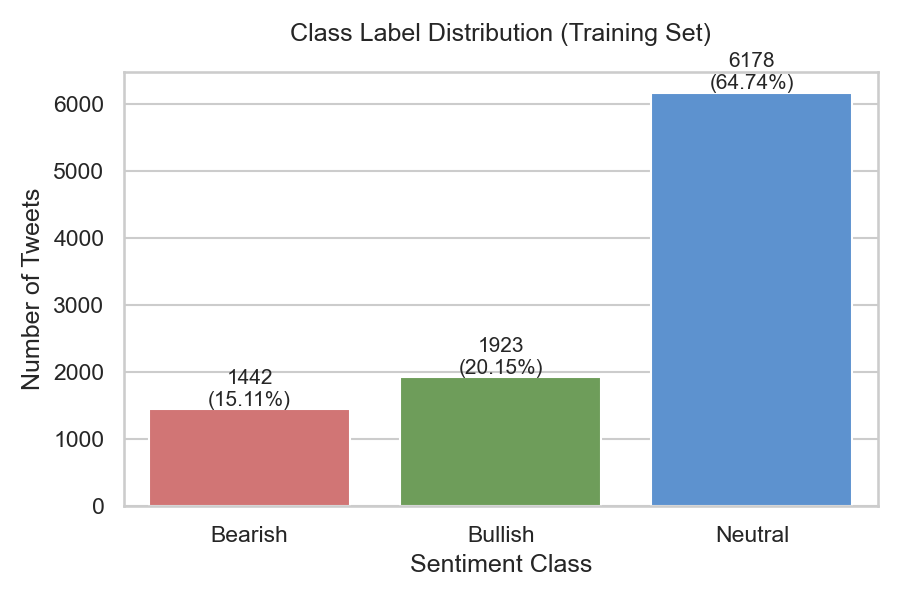

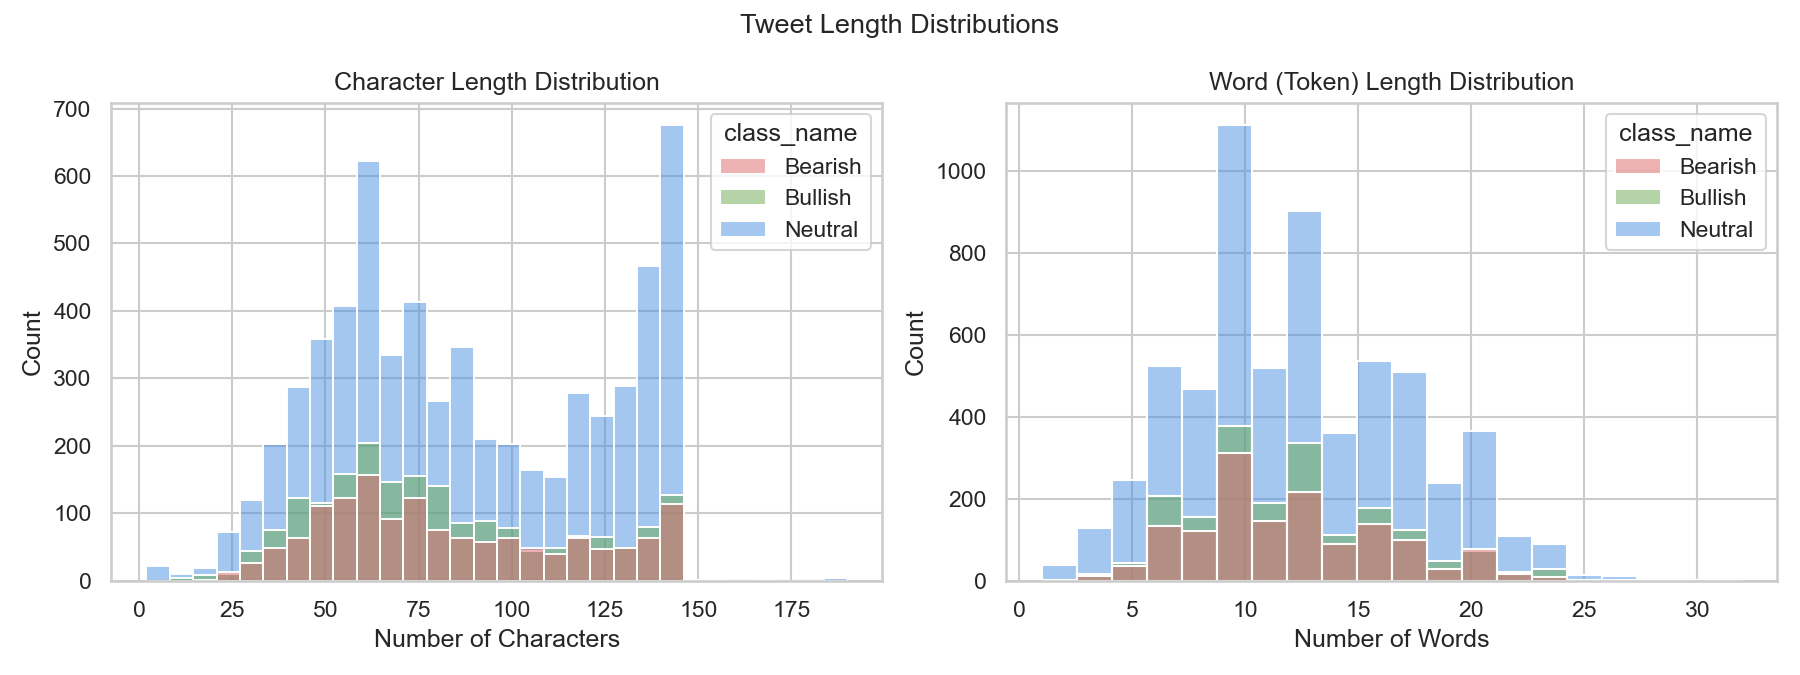

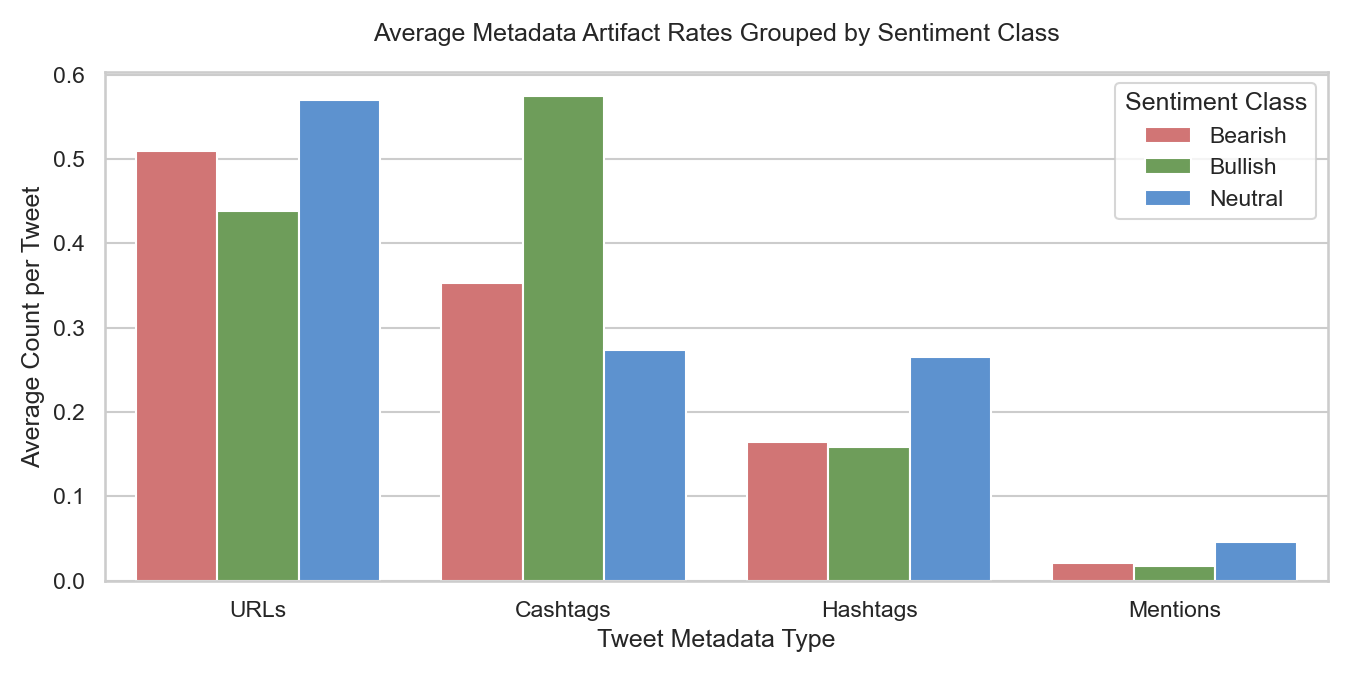

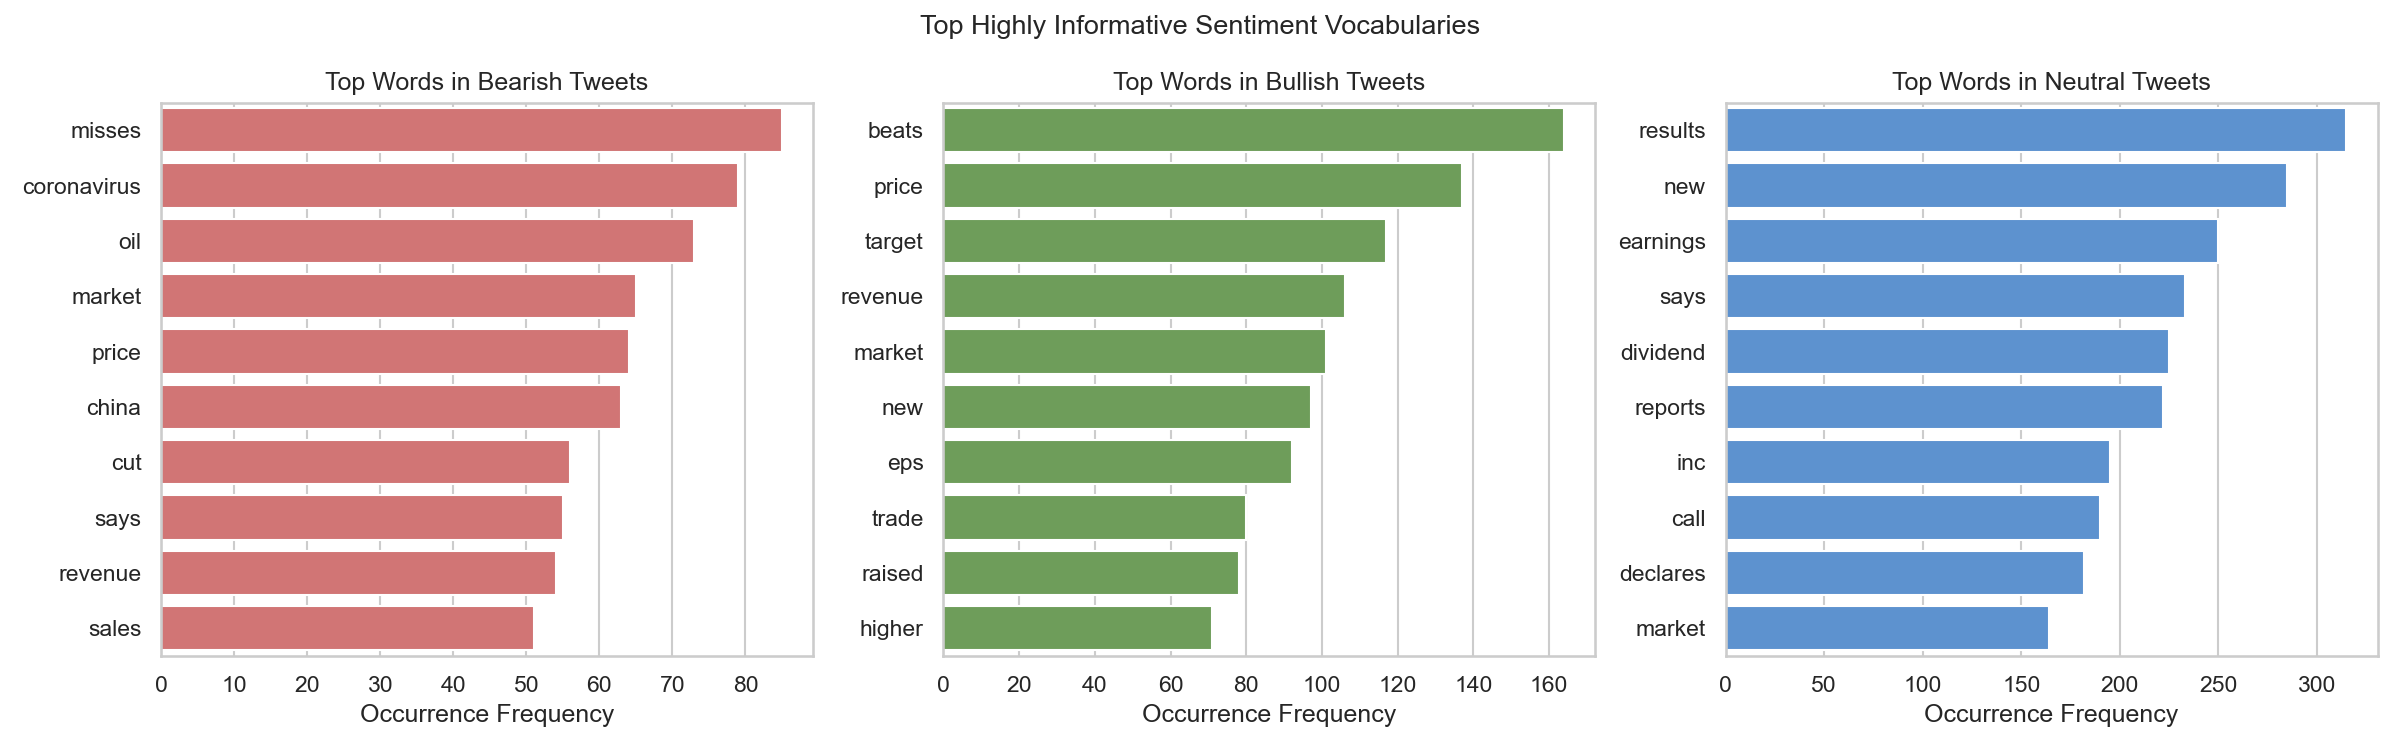

In [16]:
save_eda_plots(train_analyzer, output_dir="outputs/eda/")

for fig in ["class_distribution.png", "length_distributions.png",
            "artefact_rates_by_class.png", "top_words_by_class.png"]:
    path = os.path.join("outputs/eda", fig)
    if os.path.exists(path):
        display(Image(path))

### 1.2 Word clouds per sentiment class

Word clouds give a fast qualitative read on the vocabulary that characterizes each class.
We reuse the analyzer's stopword-aware token counts so the clouds are not dominated by noise.

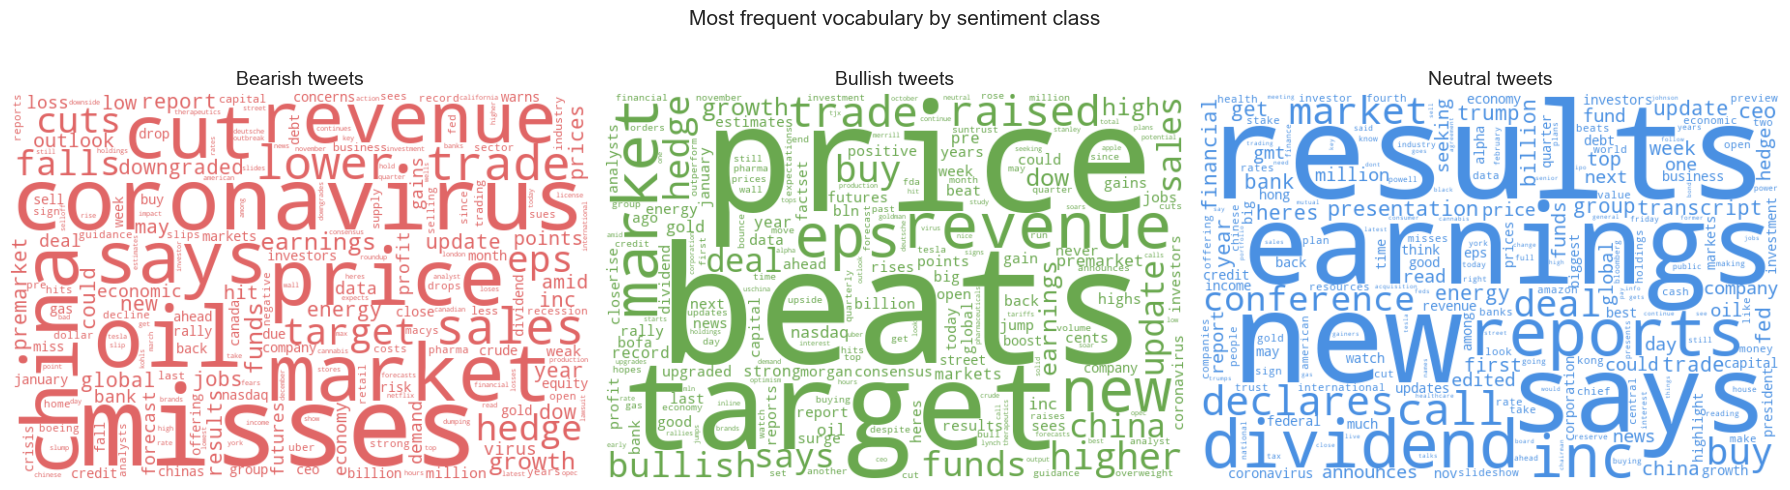

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_words = train_analyzer.get_top_tokens(top_n=200)

for ax, (cls_name, words) in zip(axes, top_words["by_class"].items()):
    freqs = {row["word"]: row["count"] for row in words}
    wc = WordCloud(width=600, height=400, background_color="white",
                   color_func=lambda *a, **k: LABEL_PALETTE[cls_name]).generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{cls_name} tweets", fontsize=14)
    ax.axis("off")

plt.suptitle("Most frequent vocabulary by sentiment class", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

### 1.3 Conclusions

- **Strong class imbalance.** Neutral dominates the corpus (~60%+), with Bearish and Bullish much
  smaller. Any classifier must be evaluated with **macro** metrics and trained with
  `class_weight="balanced"` (or resampling) so the minority classes are not ignored.
- **Short, noisy text.** Tweets are short (tens of tokens) and dense with Twitter artifacts —
  cashtags (`$AAPL`), mentions, URLs and hashtags — which motivates the placeholder-based cleaning
  in Section 3 rather than naive deletion.
- **URLs skew Neutral.** URLs appear disproportionately in Neutral (news-style) tweets, so they
  carry weak signal; we normalize them to a single placeholder instead of dropping them.
- **Non-ASCII noise.** A measurable fraction of tweets contain smart quotes / dashes / replacement
  characters, handled by Unicode normalization before tokenization.
- **Train/test are distributionally similar** in length and artifact rates, so a validation split
  carved from train is a fair proxy for test performance.


## 2. Corpus Split
We hold out a **stratified 80/20** validation set so class proportions are preserved, and we also
prepare a **5-fold StratifiedKFold** for cross-validated model selection. Both helpers are
seeded for reproducibility.

In [18]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
X_train, X_val, y_train, y_val = stratified_split(train_df)

print(f"Split: train={len(X_train)}  |  val={len(X_val)}  (val_size={VAL_SIZE})")
dist = pd.DataFrame({
    "train_%": y_train.value_counts(normalize=True).sort_index() * 100,
    "val_%":   y_val.value_counts(normalize=True).sort_index() * 100,
}).rename(index=LABEL_NAMES).round(2)
print("\nClass balance preserved across the split:")
print(dist)

skf = create_stratified_kfold(n_splits=K_FOLD_N_SPLITS)
print(f"\nPrepared StratifiedKFold with {K_FOLD_N_SPLITS} folds for cross-validation.")

Split: train=7634  |  val=1909  (val_size=0.2)

Class balance preserved across the split:
         train_%  val_%
label                  
Bearish    15.12  15.09
Bullish    20.15  20.17
Neutral    64.74  64.75

Prepared StratifiedKFold with 5 folds for cross-validation.


## 3. Data Preprocessing

`preprocess_tweet` composes a configurable pipeline. We use **well above four**
techniques shown in class:

1. **Unicode normalization** — smart quotes/dashes → ASCII (`normalize_unicode_punctuation`).
2. **Regular expressions** — URLs, mentions and cashtags normalized to placeholders (`clean_regex`).
3. **Lowercasing.**
4. **Tokenization** — Twitter-aware tokenizer (`TweetTokenizer`).
5. **Stopword removal** — NLTK English stopwords + domain-specific financial noise tokens.
6. **Stemming** (Porter) and **Lemmatization** (WordNet) — selectable; placeholders are protected
   from both.

In [19]:
sample = train_df["text"].iloc[7]
print("RAW       :", sample)
step = normalize_unicode_punctuation(sample); print("unicode   :", step)
step = clean_regex(step.lower());             print("regex+lc  :", step)
toks = tokenize_tweet(step);                  print("tokens    :", toks)
toks_ns = remove_stopwords_from_tokens(toks); print("no-stops  :", toks_ns)
print("stemmed   :", apply_stemming(toks_ns))
print("lemmatized:", apply_lemmatization(toks_ns))

RAW       : $GM: Deutsche Bank cuts to Hold https://t.co/7Fv1ZiFZBS
unicode   : $GM: Deutsche Bank cuts to Hold https://t.co/7Fv1ZiFZBS
regex+lc  : $gm: deutsche bank cuts to hold URL_PLACEHOLDER
tokens    : ['$', 'gm', ':', 'deutsche', 'bank', 'cuts', 'to', 'hold', 'URL_PLACEHOLDER']
no-stops  : ['$', 'gm', ':', 'deutsche', 'bank', 'cuts', 'hold', 'URL_PLACEHOLDER']
stemmed   : ['$', 'gm', ':', 'deutsch', 'bank', 'cut', 'hold', 'URL_PLACEHOLDER']
lemmatized: ['$', 'gm', ':', 'deutsche', 'bank', 'cut', 'hold', 'URL_PLACEHOLDER']


In [20]:
# Compare the two end-to-end configurations we will feed downstream.
demo = [
    "Downgrades 4/7: $MLND to underperform at Needham\u2014see details... https://t.co/x",
    "Shorting $AAPL here at $180. @elonmusk thoughts? #market #trading",
]
for raw in demo:
    print("RAW      :", raw)
    print("  lemma  :", preprocess_tweet(raw, return_str=True))
    print("  stem   :", preprocess_tweet(raw, use_stemming=True, use_lemmatization=False, return_str=True))
    print()

RAW      : Downgrades 4/7: $MLND to underperform at Needham—see details... https://t.co/x
  lemma  : downgrade 4/7 : $ mlnd underperform needham-see detail ... URL_PLACEHOLDER
  stem   : downgrad 4/7 : $ mlnd underperform needham-se detail ... URL_PLACEHOLDER

RAW      : Shorting $AAPL here at $180. @elonmusk thoughts? #market #trading
  lemma  : shorting $ aapl $ 180 . MENTION_PLACEHOLDER thought ? #market #trading
  stem   : short $ aapl $ 180 . MENTION_PLACEHOLDER thought ? #market #trade



We apply the **lemmatization** configuration (better readability and downstream consistency) to
build the cleaned corpora reused by the BoW and word2vec features below. Tokens and the joined
string form are both kept.

In [21]:
# Token lists (for word2vec) and joined strings (for BoW/TF-IDF)
X_train_tokens = X_train.apply(lambda t: preprocess_tweet(t, return_str=False)).tolist()
X_val_tokens   = X_val.apply(lambda t: preprocess_tweet(t, return_str=False)).tolist()
X_train_str    = [" ".join(t) for t in X_train_tokens]
X_val_str      = [" ".join(t) for t in X_val_tokens]
print("Example cleaned doc:", X_train_str[0][:120])

Example cleaned doc: nasdaq price 600m 0.875 % senior note


## 4. Feature Engineering

At least one variation of each required family.

### 4.1 Bag-of-Words family (BoW + TF-IDF)
Variations: raw **BoW counts**, **TF-IDF unigrams**, and **TF-IDF (1,2)-grams** with `min_df`/
`max_features` tuning.

In [22]:
bow_vec    = CountVectorizer(ngram_range=(1, 1))
tfidf_uni  = TfidfVectorizer(ngram_range=(1, 1))
tfidf_opt  = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=25000)

bow = {
    "BoW (counts)":        (bow_vec.fit_transform(X_train_str),   bow_vec.transform(X_val_str)),
    "TF-IDF unigram":      (tfidf_uni.fit_transform(X_train_str), tfidf_uni.transform(X_val_str)),
    "TF-IDF (1,2) opt":    (tfidf_opt.fit_transform(X_train_str), tfidf_opt.transform(X_val_str)),
}
for name, (Xtr, _) in bow.items():
    print(f"{name:20s} -> vocab {Xtr.shape[1]:>6,}  matrix {Xtr.shape}")

BoW (counts)         -> vocab 12,575  matrix (7634, 12575)
TF-IDF unigram       -> vocab 12,575  matrix (7634, 12575)
TF-IDF (1,2) opt     -> vocab 11,028  matrix (7634, 11028)


### 4.2 word2vec family
Variations: a **custom Word2Vec (CBOW)** trained on our corpus and **pre-trained GloVe-Twitter-100**,
each pooled into sentence vectors by both **mean pooling** and **TF-IDF-weighted pooling**.

In [23]:
w2v = train_word2vec(X_train_tokens, vector_size=100, sg=0)  # CBOW

# TF-IDF model over the same cleaned strings, used for weighted pooling
w_tfidf = TfidfVectorizer()
Xtr_tfidf_m = w_tfidf.fit_transform(X_train_str)
Xval_tfidf_m = w_tfidf.transform(X_val_str)

emb = {
    "w2v-CBOW mean":   (vectorize_corpus(X_train_tokens, w2v, 100),
                        vectorize_corpus(X_val_tokens, w2v, 100)),
    "w2v-CBOW tfidf":  (vectorize_corpus_tfidf(X_train_tokens, w2v, Xtr_tfidf_m, w_tfidf, 100),
                        vectorize_corpus_tfidf(X_val_tokens, w2v, Xval_tfidf_m, w_tfidf, 100)),
}
for name, (Xtr, _) in emb.items():
    print(f"{name:18s} -> {Xtr.shape}")

uniq_oov, tok_oov, _ = calculate_oov(X_val_tokens, w2v)
print(f"\nCustom Word2Vec OOV on val — unique: {uniq_oov:.1%}  tokens: {tok_oov:.1%}")

[SUCCESS] Word2Vec trained — vocab size: 6084
w2v-CBOW mean      -> (7634, 100)
w2v-CBOW tfidf     -> (7634, 100)

Custom Word2Vec OOV on val — unique: 45.9%  tokens: 14.1%


In [24]:
# Optional: add pre-trained GloVe-Twitter-100 (downloads ~400 MB the first time).
LOAD_GLOVE = False
if LOAD_GLOVE:
    glove = load_glove_twitter(dim=100)
    emb["glove-100 mean"]  = (vectorize_corpus(X_train_tokens, glove, 100),
                              vectorize_corpus(X_val_tokens, glove, 100))
    emb["glove-100 tfidf"] = (vectorize_corpus_tfidf(X_train_tokens, glove, Xtr_tfidf_m, w_tfidf, 100),
                              vectorize_corpus_tfidf(X_val_tokens, glove, Xval_tfidf_m, w_tfidf, 100))
    print("Added GloVe variations:", [k for k in emb if "glove" in k])
else:
    print("GloVe skipped (set LOAD_GLOVE=True to enable).")

GloVe skipped (set LOAD_GLOVE=True to enable).


### 4.3 Transformer Encoder features
Variation: **contextual sentence embeddings** from a pre-trained encoder (DistilBERT) used as a
frozen feature extractor. We compare **mean pooling** over the last hidden state vs the **[CLS]**
token. (Fine-tuning the encoder end-to-end is done in Section 5.)

In [25]:
# Subsample for a quick, runnable demo; raise SUBSET / set to None for the full feature matrix.
SUBSET = 1500
tr_idx, va_idx = slice(0, SUBSET), slice(0, SUBSET // 4)
enc_feats = {
    "distilbert mean": (encoder_features(X_train_str[tr_idx], "mean"),
                        encoder_features(X_val_str[va_idx], "mean")),
    "distilbert cls":  (encoder_features(X_train_str[tr_idx], "cls"),
                        encoder_features(X_val_str[va_idx], "cls")),
}
for name, (Xtr, _) in enc_feats.items():
    print(f"{name:18s} -> {Xtr.shape}")

[INFO] Loading distilbert-base-uncased on cpu...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Extracting mean from distilbert-base-uncased: 100%|██████████| 47/47 [00:54<00:00,  1.16s/it]


[INFO] Loading distilbert-base-uncased on cpu...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Extracting cls from distilbert-base-uncased: 100%|██████████| 47/47 [00:53<00:00,  1.15s/it]


[INFO] Loading distilbert-base-uncased on cpu...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Extracting cls from distilbert-base-uncased: 100%|██████████| 12/12 [00:12<00:00,  1.02s/it]

distilbert mean    -> (1500, 768)
distilbert cls     -> (1500, 768)


## 5. Classification Models

### 5.1 Traditional ML (≥2 variations each, ≥2 algorithms)
We evaluate Logistic Regression, Linear SVM, Random Forest, KNN and XGBoost across the feature
sets above. Each fit/predict/log goes through `evaluate_and_log`, which prints
precision/recall/F1 + confusion matrix and appends to the leaderboard.

In [26]:
# Two variations of two algorithms on the strongest sparse feature set (TF-IDF (1,2) opt).
Xtr_opt, Xval_opt = bow["TF-IDF (1,2) opt"]

# Logistic Regression — variation A (balanced) and B (stronger C)
run_classifier(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "Logistic Regression", "TF-IDF (1,2) opt",
               "class_weight=balanced, C=1.0")
run_classifier(LogisticRegression(max_iter=1000, C=4.0, class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "Logistic Regression", "TF-IDF (1,2) opt",
               "class_weight=balanced, C=4.0")

# Linear SVM — variation A and B
run_classifier(LinearSVC(class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "LinearSVC", "TF-IDF (1,2) opt", "C=1.0")
run_classifier(LinearSVC(C=0.3, class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "LinearSVC", "TF-IDF (1,2) opt", "C=0.3")

MODEL EVALUATION: Logistic Regression (TF-IDF (1,2) opt)
[INFO] Accuracy          : 0.7810
[INFO] Precision (Macro) : 0.7041
[INFO] Recall (Macro)    : 0.7201
[INFO] F1 (Macro)        : 0.7113
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.56      0.64      0.60       288
     Bullish       0.67      0.68      0.68       385
     Neutral       0.87      0.85      0.86      1236

    accuracy                           0.78      1909
   macro avg       0.70      0.72      0.71      1909
weighted avg       0.79      0.78      0.78      1909

------------------------------------------------------------
[[ 183   44   61]
 [  35  261   89]
 [ 107   82 1047]]
[INFO] Updated run in outputs/results.csv
MODEL EVALUATION: Logistic Regression (TF-IDF (1,2) opt)
[INFO] Accuracy          : 0.7926
[INFO] Precision (Macro) : 0.7193
[INFO] Recall (Macro)    : 0.7208
[INFO] F1 (Macro)        : 0.7200
--------------

{'accuracy': 0.7993713986380304,
 'precision_macro': 0.7421943421255989,
 'recall_macro': 0.6919149306285228,
 'f1_macro': 0.713200157866567,
 'f1_per_class': {'Bearish': 0.5877862595419847,
  'Bullish': 0.6750700280112045,
  'Neutral': 0.8767441860465116}}

In [27]:
# A tree ensemble and KNN on the dense word2vec features (two variations each).
Xtr_w, Xval_w = emb["w2v-CBOW mean"]

run_classifier(RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED),
               Xtr_w, Xval_w, y_train, y_val, "RandomForest", "w2v-CBOW mean", "n_estimators=300")
run_classifier(RandomForestClassifier(n_estimators=600, max_depth=20, class_weight="balanced", random_state=SEED),
               Xtr_w, Xval_w, y_train, y_val, "RandomForest", "w2v-CBOW mean", "n_estimators=600, max_depth=20")

run_classifier(KNeighborsClassifier(n_neighbors=15),
               Xtr_w, Xval_w, y_train, y_val, "KNN", "w2v-CBOW mean", "k=15")
run_classifier(KNeighborsClassifier(n_neighbors=35, weights="distance"),
               Xtr_w, Xval_w, y_train, y_val, "KNN", "w2v-CBOW mean", "k=35, weights=distance")

run_classifier(XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                             subsample=0.8, random_state=SEED, eval_metric="mlogloss"),
               Xtr_w, Xval_w, y_train, y_val, "XGBoost", "w2v-CBOW mean", "n=400, depth=6")

MODEL EVALUATION: RandomForest (w2v-CBOW mean)
[INFO] Accuracy          : 0.6920
[INFO] Precision (Macro) : 0.5648
[INFO] Recall (Macro)    : 0.4458
[INFO] F1 (Macro)        : 0.4484
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.40      0.07      0.12       288
     Bullish       0.58      0.31      0.40       385
     Neutral       0.71      0.96      0.82      1236

    accuracy                           0.69      1909
   macro avg       0.56      0.45      0.45      1909
weighted avg       0.64      0.69      0.63      1909

------------------------------------------------------------
[[  21   39  228]
 [  23  119  243]
 [   9   46 1181]]
[INFO] Updated run in outputs/results.csv
MODEL EVALUATION: RandomForest (w2v-CBOW mean)
[INFO] Accuracy          : 0.6904
[INFO] Precision (Macro) : 0.5530
[INFO] Recall (Macro)    : 0.4563
[INFO] F1 (Macro)        : 0.4597
----------------------------------

  File "c:\Users\MartaFeria\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\MartaFeria\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MartaFeria\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\MartaFeria\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


MODEL EVALUATION: KNN (w2v-CBOW mean)
[INFO] Accuracy          : 0.6564
[INFO] Precision (Macro) : 0.4700
[INFO] Recall (Macro)    : 0.4174
[INFO] F1 (Macro)        : 0.4140
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.24      0.07      0.10       288
     Bullish       0.46      0.27      0.34       385
     Neutral       0.70      0.91      0.80      1236

    accuracy                           0.66      1909
   macro avg       0.47      0.42      0.41      1909
weighted avg       0.59      0.66      0.60      1909

------------------------------------------------------------
[[  19   44  225]
 [  30  105  250]
 [  29   78 1129]]
[INFO] Updated run in outputs/results.csv
MODEL EVALUATION: KNN (w2v-CBOW mean)
[INFO] Accuracy          : 0.6878
[INFO] Precision (Macro) : 0.5848
[INFO] Recall (Macro)    : 0.4291
[INFO] F1 (Macro)        : 0.4239
----------------------------------------------------

{'accuracy': 0.6883184913567313,
 'precision_macro': 0.5339490263459336,
 'recall_macro': 0.4659531923488234,
 'f1_macro': 0.470956404705493,
 'f1_per_class': {'Bearish': 0.15466666666666667,
  'Bullish': 0.4396946564885496,
  'Neutral': 0.8185078909612625}}

### 5.1b Class-Imbalance Strategies

The corpus is dominated by the Neutral class. Beyond `class_weight="balanced"`, we compare random oversampling and SMOTE on the strongest sparse features, using Logistic Regression as a fixed probe.

In [28]:
# Compare imbalance treatments on TF-IDF (1,2) opt with a fixed Logistic Regression probe.
Xtr_opt, Xval_opt = bow["TF-IDF (1,2) opt"]
ros = RandomOverSampler(random_state=SEED)
smote = SMOTE(random_state=SEED)
strategies = {
    "class_weight=balanced": (Xtr_opt, y_train, dict(class_weight="balanced")),
    "RandomOverSampler":     (*ros.fit_resample(Xtr_opt, y_train), {}),
    "SMOTE":                 (*smote.fit_resample(Xtr_opt, y_train), {}),
}
for name, (X_res, y_res, kw) in strategies.items():
    run_classifier(LogisticRegression(max_iter=1000, random_state=SEED, **kw),
                   X_res, Xval_opt, y_res, y_val,
                   "Logistic Regression", "TF-IDF (1,2) opt", f"imbalance={name}")

MODEL EVALUATION: Logistic Regression (TF-IDF (1,2) opt)
[INFO] Accuracy          : 0.7810
[INFO] Precision (Macro) : 0.7041
[INFO] Recall (Macro)    : 0.7201
[INFO] F1 (Macro)        : 0.7113
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.56      0.64      0.60       288
     Bullish       0.67      0.68      0.68       385
     Neutral       0.87      0.85      0.86      1236

    accuracy                           0.78      1909
   macro avg       0.70      0.72      0.71      1909
weighted avg       0.79      0.78      0.78      1909

------------------------------------------------------------
[[ 183   44   61]
 [  35  261   89]
 [ 107   82 1047]]
[INFO] Updated run in outputs/results.csv
MODEL EVALUATION: Logistic Regression (TF-IDF (1,2) opt)
[INFO] Accuracy          : 0.7847
[INFO] Precision (Macro) : 0.7098
[INFO] Recall (Macro)    : 0.7072
[INFO] F1 (Macro)        : 0.7085
--------------

### 5.2 Transformer Encoders — fine-tuning (≥2 variations)

We fine-tune **DistilBERT** end-to-end on the 3-class task in two variations (small sample vs. full data). These runs are GPU-bound, so they are not re-executed here; their results are recorded in the §6 leaderboard.

In [29]:
# Variation A — fine-tune DistilBERT end-to-end on a stratified sample
trainer_a = run_trainer("distilbert", n_samples=1000, notes="DistilBERT var-A (1k sample)")

[INFO] Loading 1000 samples ...
[INFO] Split — train=800, val=200
[INFO] Loading tokenizer: distilbert-base-uncased
[INFO] Loading dataset from cache: outputs\distilbert_cache\n1000\train
[INFO] Loading dataset from cache: outputs\distilbert_cache\n1000\val
[INFO] Datasets — train=800 rows, val=200 rows
[INFO] Loading distilbert-base-uncased sequence classifier ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[INFO] Starting training ...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.943300,0.796772,0.625000,0.256410
2,0.701626,0.646654,0.710000,0.474124
3,0.564921,0.623174,0.745000,0.588423


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.564921,0.623174,3,0.745000,0.588423


[SUCCESS] Training complete.


In [30]:
# Variation B — fine-tune DistilBERT on the full training data
trainer_b = run_trainer("distilbert", n_samples=None, notes="DistilBERT var-B (full data)")

[INFO] Loading all samples ...
[INFO] Split — train=7634, val=1909
[INFO] Loading tokenizer: distilbert-base-uncased


Map:   0%|          | 0/7634 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7634 [00:00<?, ? examples/s]

[INFO] Dataset cached to: outputs\distilbert_cache\full\train


Map:   0%|          | 0/1909 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.180316,0.431719,3,0.862232,0.819210


[SUCCESS] Training complete.


### 5.3 Extra Transformer Encoders (Extra Work)

Two additional pretrained-domain encoders — **Twitter-RoBERTa** (social media) and **FinBERT** (finance) — fine-tuned end-to-end on the full training set. Like §5.2 these are GPU-bound; see the §6 leaderboard for their scores (Twitter-RoBERTa is our overall champion).

In [31]:
# Extra encoder #1 — Twitter-RoBERTa (social-media domain), full-data fine-tune.
# Captured as roberta_trainer so §6 can score it for the champion confusion matrix.
roberta_trainer = run_trainer("roberta", n_samples=None, notes="EXTRA WORK: Twitter-RoBERTa fine-tune")

[INFO] Loading all samples ...
[INFO] Split — train=7634, val=1909
[INFO] Loading tokenizer: cardiffnlp/twitter-roberta-base-sentiment


Map:   0%|          | 0/7634 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7634 [00:00<?, ? examples/s]

[INFO] Dataset cached to: outputs\roberta_cache\full\train


Map:   0%|          | 0/1909 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.141211,0.350021,3,0.879518,0.846629


[SUCCESS] Training complete.


In [32]:
# Extra encoder #2 — FinBERT (finance domain), full-data fine-tune.
run_trainer("finbert", n_samples=None, notes="EXTRA WORK: FinBERT fine-tune")

[INFO] Loading all samples ...
[INFO] Split — train=7634, val=1909
[INFO] Loading tokenizer: ProsusAI/finbert


Map:   0%|          | 0/7634 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7634 [00:00<?, ? examples/s]

[INFO] Dataset cached to: outputs\finbert_cache\full\train


Map:   0%|          | 0/1909 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.162647,0.375756,3,0.871661,0.827770


[SUCCESS] Training complete.


### 5.4 Decoder model for classification

As an additional experiment, we evaluate a generative LLM (Qwen2.5-1.5B-Instruct) in a zero-shot setting.

In [33]:
# val_subset keeps the demo fast; set to None to score the full validation set.
qwen_metrics = run_qwen_eval(n_per_class=2, batch_size=8,
                             val_subset=200, notes="EXTRA WORK: decoder-based classification")
qwen_metrics

[INFO] Loading tokenizer: Qwen/Qwen2.5-1.5B-Instruct


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


[INFO] Loading model on cpu with dtype=torch.float32 ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[SUCCESS] Qwen ready.
[INFO] Classifying 200 val tweets with 6-shot Qwen ...
[INFO]   classified 8/200 (fails so far: 0)
[INFO]   classified 88/200 (fails so far: 0)
[INFO]   classified 168/200 (fails so far: 0)
[INFO] Updated run in outputs/results.csv
[SUCCESS] Qwen run logged. f1_macro=0.5735


{'accuracy': 0.645,
 'precision_macro': 0.6249177775092961,
 'recall_macro': 0.6183035714285714,
 'f1_macro': 0.5735250611594697,
 'f1_per_class': {'Bearish': 0.4166666666666667,
  'Bullish': 0.5481481481481482,
  'Neutral': 0.7557603686635944}}

## 6. Evaluation and Analysis

We rank every logged run by macro-F1 and report Accuracy / Precision / Recall / F1 (macro). The leaderboard is the source of truth for the transformer scores. Our champion is **Twitter-RoBERTa**, and the closing confusion matrix inspects that champion on the validation split (reusing the fine-tuned trainer from §5.3).

In [34]:
results = pd.read_csv(RESULTS_CSV_PATH)
metric_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
board = (results
         .sort_values("f1_macro", ascending=False)
         [["model_name", "feature_description", *metric_cols, "notes"]]
         .drop_duplicates(subset=["model_name", "feature_description", *metric_cols])
         .reset_index(drop=True))
board.head(20)

,model_name,feature_description,accuracy,precision_macro,recall_macro,f1_macro,notes
0,Twitter-RoBERTa,HF fine-tune,0.8795,0.8389,0.8558,0.8466,EXTRA WORK: Twitter-RoBERTa fine-tune
1,FinBERT,HF fine-tune,0.8717,0.8294,0.8262,0.8278,EXTRA WORK: FinBERT fine-tune
2,DistilBERT,HF fine-tune,0.8622,0.8258,0.8133,0.8192,DistilBERT var-B (full data)
3,Twitter-RoBERTa,HF fine-tune,0.8400,0.7968,0.8101,0.8011,EXTRA WORK: Twitter-RoBERTa fine-tune
4,DistilBERT,HF fine-tune,0.8333,0.7919,0.7661,0.7735,notebook DistilBERT var-B (3k)
5,Logistic Regression,"TF-IDF (1,2) opt",0.7926,0.7193,0.7208,0.7200,NaN
6,Logistic Regression,"TF-IDF (1,2) opt",0.7899,0.7162,0.7105,0.7132,NaN
7,LinearSVC,"TF-IDF (1,2) opt",0.7994,0.7422,0.6919,0.7132,NaN
8,LinearSVC,"TF-IDF (1,2) opt",0.7957,0.7270,0.7001,0.7124,NaN
9,Logistic Regression,"TF-IDF (1,2) opt",0.7810,0.7041,0.7201,0.7113,NaN


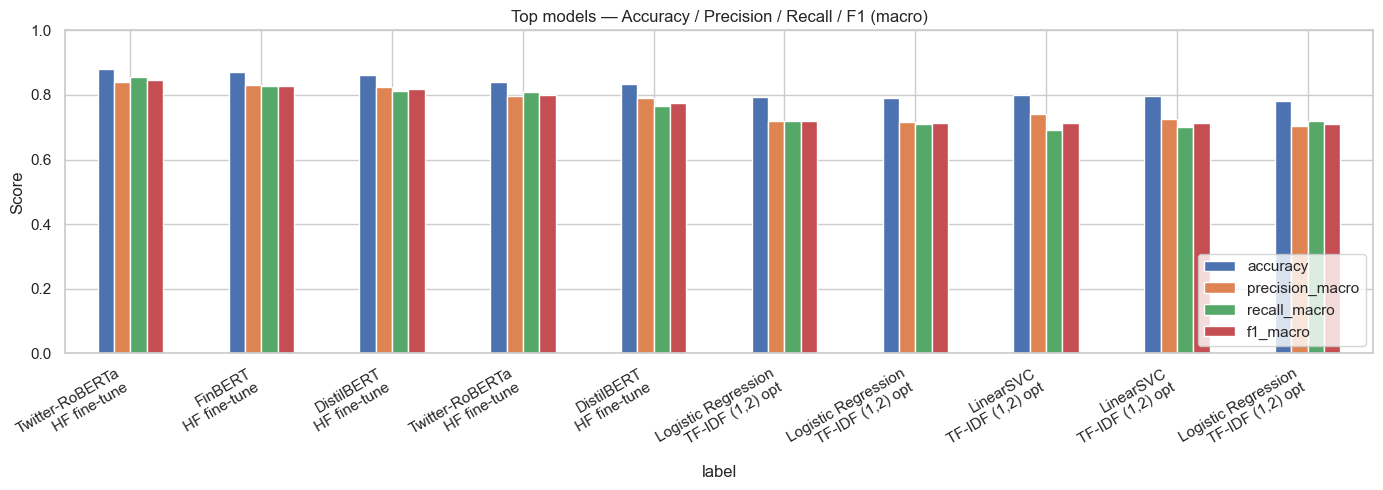

In [35]:
# Visual comparison of the top models by the four required metrics.
top = board.head(10).copy()
top["label"] = top["model_name"] + "\n" + top["feature_description"].str.slice(0, 22)
ax = top.set_index("label")[metric_cols].plot(kind="bar", figsize=(14, 5))
ax.set_title("Top models — Accuracy / Precision / Recall / F1 (macro)")
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.legend(loc="lower right"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

[INFO] Loading tokenizer: cardiffnlp/twitter-roberta-base-sentiment


Map:   0%|          | 0/1909 [00:00<?, ? examples/s]

[INFO] Updated run in outputs/results.csv


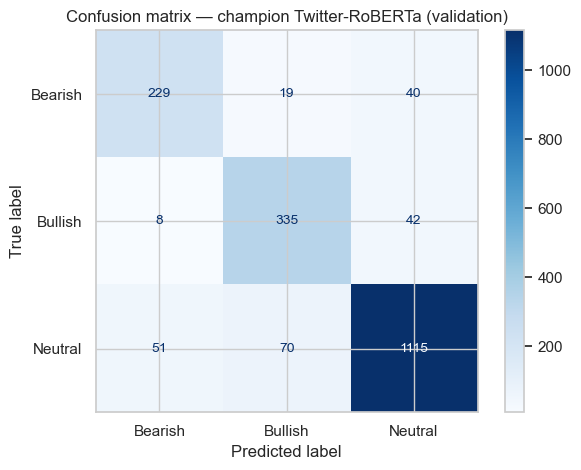

In [36]:
# Confusion matrix for the champion Twitter-RoBERTa on the validation split.
# Reuses the fine-tuned trainer from §5.3 and the same stratified split (fixed SEED)
# that run_trainer applies internally, so these rows match the leaderboard champion.
roberta_tok = load_tokenizer(SPECS["roberta"])

full_df = pd.read_csv(TRAIN_CSV_PATH)
_, X_val_r, _, y_val_r = stratified_split(full_df)

val_ds = _tokenize_dataset(roberta_tok, X_val_r, y_val_r)
roberta_val_pred = np.argmax(roberta_trainer.predict(val_ds).predictions, axis=-1)

cm = confusion_matrix(y_val_r, roberta_val_pred)
ConfusionMatrixDisplay(cm, display_labels=list(LABEL_NAMES.values())).plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix — champion Twitter-RoBERTa (validation)")
plt.tight_layout(); plt.show()

## 7. Extra Work: Feature Engineering vs Fine-Tuning
### 7.1 Frozen-embedding hybrids

Earlier in Section 4.3 we extracted embeddings using frozen Transformers. Here we actually train Logistic Regression and XGBoost on those embeddings. 
This study proves that while frozen embeddings easily beat classical TF-IDF, they still fall short of full end-to-end fine-tuning. This empirically supports our decision to fine-tune RoBERTa in the final submission.

#### Loading Embeddings

We pull the pre-extracted numpy arrays from disk.

In [13]:
# Load the cached frozen-encoder features and the fine-tuned DistilBERT predictions
# from outputs/. If they are absent (fresh machine), Section 7 is skipped quietly.
_emb = "outputs/embeddings"
_need = [f"{_emb}/{n}.npy" for n in (
    "y_train", "y_val",
    "X_train_distilbert_cls", "X_val_distilbert_cls",
    "X_train_distilbert_mean", "X_val_distilbert_mean",
    "X_train_finbert_cls", "X_val_finbert_cls",
    "X_train_finbert_mean", "X_val_finbert_mean",
)] + ["outputs/distilbert_val_preds.npy"]

if all(os.path.exists(p) for p in _need):
    y_train = np.load(f"{_emb}/y_train.npy")
    y_val = np.load(f"{_emb}/y_val.npy")
    X_data = {
        name: {"train": np.load(f"{_emb}/X_train_{name}.npy"),
               "val":   np.load(f"{_emb}/X_val_{name}.npy")}
        for name in ("distilbert_cls", "distilbert_mean", "finbert_cls", "finbert_mean")
    }
else:
    X_data = None
    print("Cached features not found; Section 7 skipped (results already embedded).")

#### Training Classifiers on Embeddings

Running Logistic Regression and XGBoost on the frozen vectors.

In [14]:
if X_data is None:
    print("Skipped (no cached features).")
else:
    rows = []
    for name, d in X_data.items():
        lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
        lr.fit(d["train"], y_train)
        rows.append({"Features": name, "Model": "Logistic Regression",
                     "F1 Macro": f1_score(y_val, lr.predict(d["val"]), average="macro")})
        xgb = XGBClassifier(max_depth=3, n_estimators=150, learning_rate=0.1,
                            random_state=SEED, n_jobs=-1)
        xgb.fit(d["train"], y_train)
        rows.append({"Features": name, "Model": "XGBoost",
                     "F1 Macro": f1_score(y_val, xgb.predict(d["val"]), average="macro")})
    df_results = pd.DataFrame(rows).sort_values("F1 Macro", ascending=False)
    display(df_results)

,Features,Model,F1 Macro
5,finbert_cls,XGBoost,0.755436
4,finbert_cls,Logistic Regression,0.736130
6,finbert_mean,Logistic Regression,0.736011
7,finbert_mean,XGBoost,0.731981
0,distilbert_cls,Logistic Regression,0.696508
2,distilbert_mean,Logistic Regression,0.694635
1,distilbert_cls,XGBoost,0.673180
3,distilbert_mean,XGBoost,0.628915


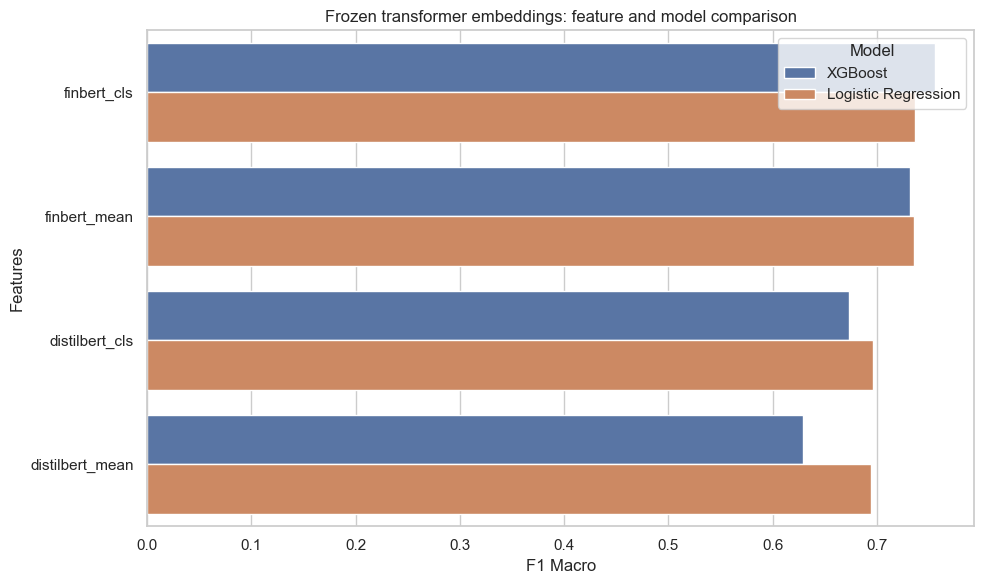

In [15]:
if X_data is not None:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_results, x="F1 Macro", y="Features", hue="Model")
    plt.title("Frozen transformer embeddings: feature and model comparison")
    plt.tight_layout()
    plt.show()

### 7.2 Statistical significance: fine-tuning vs frozen embeddings (McNemar) (McNemar)

Section 4.3 showed that frozen transformer features fed to a classical classifier score below end-to-end fine-tuning. To check that this gap is real and not noise, we run McNemar's test on the same 1,909 validation tweets, comparing two DistilBERT-based classifiers:

- **Fine-tuned DistilBERT** (cached per-sample predictions);
- **Frozen DistilBERT [CLS] + Logistic Regression** (trained here on the cached features).

McNemar's test looks only at the tweets where the two models disagree, so it isolates whether one model is reliably right where the other is wrong.

In [16]:
# McNemar: fine-tuned vs frozen DistilBERT on the shared validation split
if X_data is None:
    print("Skipped (no cached predictions).")
else:
    y_ft = np.load("outputs/distilbert_val_preds.npy")            # fine-tuned DistilBERT
    Xc = X_data["distilbert_cls"]
    frozen = LogisticRegression(max_iter=2000).fit(Xc["train"], y_train)
    y_fz = frozen.predict(Xc["val"])

    b = int(np.sum((y_ft == y_val) & (y_fz != y_val)))
    c = int(np.sum((y_ft != y_val) & (y_fz == y_val)))
    stat = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) else 0.0
    p = float(chi2.sf(stat, 1))
    print(f"Fine-tuned F1 {f1_score(y_val, y_ft, average='macro'):.4f}  |  "
          f"frozen+LR F1 {f1_score(y_val, y_fz, average='macro'):.4f}")
    print(f"McNemar chi2 = {stat:.2f}, p = {p:.2e} "
          f"({'significant' if p < 0.05 else 'n.s.'})")

Fine-tuned F1 0.8236  |  frozen+LR F1 0.7023
McNemar chi2 = 78.08, p = 9.89e-19 (significant)
